# Load CMS Data

In [18]:
import requests
import pandas as pd

BASE_URL = "https://data.cms.gov/data-api/v1/dataset/92396110-2aed-4d63-a6a2-5d6207d46a29/data"
PAGE_SIZE = 5000
MAX_ROWS = 100_000

_records = []
_offset = 0

print("Fetching data from CMS API (capped at 100,000 rows)...")
while len(_records) < MAX_ROWS:
    _fetch = min(PAGE_SIZE, MAX_ROWS - len(_records))
    _resp = requests.get(BASE_URL, params={"size": _fetch, "offset": _offset}, timeout=60)
    _resp.raise_for_status()
    _page = _resp.json()
    if not _page:
        break
    _records.extend(_page)
    _offset += len(_page)
    print(f"  Retrieved {len(_records):,} records so far...")
    if len(_page) < _fetch:
        break

raw_df = pd.DataFrame(_records)

print(f"\n{'='*55}")
print(f"Dataset Shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
print(f"{'='*55}")

print("\n--- Column Names & Data Types ---")
_dtype_df = pd.DataFrame({
    "Column": raw_df.columns,
    "Dtype": raw_df.dtypes.values
})
print(_dtype_df.to_string(index=False))


Fetching data from CMS API (capped at 100,000 rows)...
  Retrieved 5,000 records so far...
  Retrieved 10,000 records so far...
  Retrieved 15,000 records so far...
  Retrieved 20,000 records so far...
  Retrieved 25,000 records so far...
  Retrieved 30,000 records so far...
  Retrieved 35,000 records so far...
  Retrieved 40,000 records so far...
  Retrieved 45,000 records so far...
  Retrieved 50,000 records so far...
  Retrieved 55,000 records so far...
  Retrieved 60,000 records so far...
  Retrieved 65,000 records so far...
  Retrieved 70,000 records so far...
  Retrieved 75,000 records so far...
  Retrieved 80,000 records so far...
  Retrieved 85,000 records so far...
  Retrieved 90,000 records so far...
  Retrieved 95,000 records so far...
  Retrieved 100,000 records so far...

Dataset Shape: 100,000 rows × 28 columns

--- Column Names & Data Types ---
                       Column  Dtype
                   Rndrng_NPI object
   Rndrng_Prvdr_Last_Org_Name object
      Rndrng_Prvd

# Data Profiling


In [19]:
import pandas as pd

# ── Missing values summary ──────────────────────────────────────────────
_missing_count = raw_df.isnull().sum()
_missing_pct   = (_missing_count / len(raw_df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Column":        raw_df.columns,
    "Missing_Count": _missing_count.values,
    "Missing_Pct":   _missing_pct.values,
    "Dtype":         raw_df.dtypes.values
})
missing_summary = missing_summary.sort_values("Missing_Count", ascending=False).reset_index(drop=True)

print("=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)
print(missing_summary.to_string(index=False))

# ── Blank-string check (CMS often stores missing as "") ─────────────────
_blank_count = (raw_df == "").sum()
_blank_df = pd.DataFrame({
    "Column":      raw_df.columns,
    "Blank_Count": _blank_count.values,
    "Blank_Pct":   (_blank_count / len(raw_df) * 100).round(2).values
}).query("Blank_Count > 0").sort_values("Blank_Count", ascending=False).reset_index(drop=True)

print(f"\n{'='*60}")
print("BLANK STRING VALUES (stored as empty string '')")
print("=" * 60)
if _blank_df.empty:
    print("  None found.")
else:
    print(_blank_df.to_string(index=False))

# ── Duplicate rows ──────────────────────────────────────────────────────
_dup_count = raw_df.duplicated().sum()
_dup_key_count = raw_df.duplicated(subset=["Rndrng_NPI", "HCPCS_Cd", "Place_Of_Srvc"]).sum()

print(f"\n{'='*60}")
print("DUPLICATE ROWS SUMMARY")
print("=" * 60)
print(f"  Fully duplicate rows        : {_dup_count:,}")
print(f"  Key-level duplicates        : {_dup_key_count:,}")
print(f"  (Key = Rndrng_NPI + HCPCS_Cd + Place_Of_Srvc)")

# ── Dataset snapshot ────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Total rows    : {raw_df.shape[0]:,}")
print(f"  Total columns : {raw_df.shape[1]}")
print(f"  Memory usage  : {raw_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

MISSING VALUES SUMMARY
                       Column  Missing_Count  Missing_Pct  Dtype
                   Rndrng_NPI              0         0.00 object
   Rndrng_Prvdr_Last_Org_Name              0         0.00 object
            Avg_Mdcr_Pymt_Amt              0         0.00 object
           Avg_Mdcr_Alowd_Amt              0         0.00 object
               Avg_Sbmtd_Chrg              0         0.00 object
           Tot_Bene_Day_Srvcs              0         0.00 object
                    Tot_Srvcs              0         0.00 object
                    Tot_Benes              0         0.00 object
                Place_Of_Srvc              0         0.00 object
               HCPCS_Drug_Ind              0         0.00 object
                   HCPCS_Desc              0         0.00 object
                     HCPCS_Cd              0         0.00 object
Rndrng_Prvdr_Mdcr_Prtcptg_Ind              0         0.00 object
            Rndrng_Prvdr_Type              0         0.00 object
  

# Data Cleaning

In [20]:
import pandas as pd
import numpy as np

# ── 1. Standardize column names ─────────────────────────────────────────
_col_map = {
    "Rndrng_NPI":                   "npi",
    "Rndrng_Prvdr_Last_Org_Name":   "provider_last_org_name",
    "Rndrng_Prvdr_First_Name":      "provider_first_name",
    "Rndrng_Prvdr_MI":              "provider_middle_initial",
    "Rndrng_Prvdr_Crdntls":         "provider_credentials",
    "Rndrng_Prvdr_Ent_Cd":          "provider_entity_code",
    "Rndrng_Prvdr_St1":             "provider_street_1",
    "Rndrng_Prvdr_St2":             "provider_street_2",
    "Rndrng_Prvdr_City":            "provider_city",
    "Rndrng_Prvdr_State_Abrvtn":    "provider_state",
    "Rndrng_Prvdr_State_FIPS":      "provider_state_fips",
    "Rndrng_Prvdr_Zip5":            "provider_zip",
    "Rndrng_Prvdr_RUCA":            "provider_ruca",
    "Rndrng_Prvdr_RUCA_Desc":       "provider_ruca_desc",
    "Rndrng_Prvdr_Cntry":           "provider_country",
    "Rndrng_Prvdr_Type":            "provider_type",
    "Rndrng_Prvdr_Mdcr_Prtcptg_Ind":"medicare_participating",
    "HCPCS_Cd":                     "hcpcs_code",
    "HCPCS_Desc":                   "hcpcs_desc",
    "HCPCS_Drug_Ind":               "hcpcs_drug_flag",
    "Place_Of_Srvc":                "place_of_service",
    "Tot_Benes":                    "total_beneficiaries",
    "Tot_Srvcs":                    "total_services",
    "Tot_Bene_Day_Srvcs":           "total_beneficiary_day_services",
    "Avg_Sbmtd_Chrg":               "avg_submitted_charge",
    "Avg_Mdcr_Alowd_Amt":           "avg_medicare_allowed_amt",
    "Avg_Mdcr_Pymt_Amt":            "avg_medicare_payment_amt",
    "Avg_Mdcr_Stdzd_Amt":           "avg_medicare_standardized_amt",
}

claims_df = raw_df.rename(columns=_col_map)

# ── 2. Replace blank strings with NaN ───────────────────────────────────
_blank_cols = [
    "provider_street_2",
    "provider_middle_initial",
    "provider_credentials",
    "provider_first_name",
    "provider_ruca",
    "provider_ruca_desc",
]
for _col in _blank_cols:
    claims_df[_col] = claims_df[_col].replace("", np.nan)

# ── 3. Handle missing values ─────────────────────────────────────────────
# Optional / supplemental fields → fill with "Unknown" or "N/A"
claims_df["provider_street_2"]       = claims_df["provider_street_2"].fillna("N/A")
claims_df["provider_middle_initial"] = claims_df["provider_middle_initial"].fillna("N/A")
claims_df["provider_credentials"]    = claims_df["provider_credentials"].fillna("Unknown")
claims_df["provider_first_name"]     = claims_df["provider_first_name"].fillna("Unknown")

# RUCA: small % missing — fill description; code kept as-is (rare)
claims_df["provider_ruca_desc"] = claims_df["provider_ruca_desc"].fillna("Unknown")
claims_df["provider_ruca"]      = claims_df["provider_ruca"].fillna("Unknown")

# ── 4. Cast numeric columns ──────────────────────────────────────────────
_numeric_cols = [
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amt",
    "avg_medicare_payment_amt",
    "avg_medicare_standardized_amt",
]
for _col in _numeric_cols:
    claims_df[_col] = pd.to_numeric(claims_df[_col], errors="coerce")

# ── 5. Remove duplicate rows ─────────────────────────────────────────────
_before = len(claims_df)
claims_df = claims_df.drop_duplicates().reset_index(drop=True)
_after = len(claims_df)

# ── 6. Strip whitespace from string columns ──────────────────────────────
_str_cols = claims_df.select_dtypes(include="object").columns
for _col in _str_cols:
    claims_df[_col] = claims_df[_col].str.strip()

# ── 7. Validation report ─────────────────────────────────────────────────
print("=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)
print(f"  Rows before dedup    : {_before:,}")
print(f"  Rows after dedup     : {_after:,}")
print(f"  Rows removed         : {_before - _after:,}")
print(f"  Final shape          : {claims_df.shape[0]:,} rows × {claims_df.shape[1]} columns")

print(f"\n{'='*60}")
print("STANDARDIZED COLUMN NAMES")
print("=" * 60)
for _c in claims_df.columns:
    print(f"  {_c:<38} {claims_df[_c].dtype}")

print(f"\n{'='*60}")
print("REMAINING NULLS AFTER CLEANING")
print("=" * 60)
_null_check = claims_df.isnull().sum()
_nulls_left  = _null_check[_null_check > 0]
if _nulls_left.empty:
    print("  ✓ No null values remaining.")
else:
    print(_nulls_left.to_string())

print(f"\n{'='*60}")
print("NUMERIC COLUMNS — DESCRIPTIVE STATS")
print("=" * 60)
print(claims_df[_numeric_cols].describe().round(2).to_string())

CLEANING SUMMARY
  Rows before dedup    : 100,000
  Rows after dedup     : 100,000
  Rows removed         : 0
  Final shape          : 100,000 rows × 28 columns

STANDARDIZED COLUMN NAMES
  npi                                    object
  provider_last_org_name                 object
  provider_first_name                    object
  provider_middle_initial                object
  provider_credentials                   object
  provider_entity_code                   object
  provider_street_1                      object
  provider_street_2                      object
  provider_city                          object
  provider_state                         object
  provider_state_fips                    object
  provider_zip                           object
  provider_ruca                          object
  provider_ruca_desc                     object
  provider_country                       object
  provider_type                          object
  medicare_participating                 obj

# TOP 5 Providers by Composite Activity Score

*This ranks providers by billing **volume/activity** (services, beneficiaries, charge amount, claim lines). It is not a fraud signal — a large, entirely legitimate high-volume provider scores identically to a fraudulent one here. See "Fraud Detection — Risk Flags" below for the actual anomaly-based flags.*


TOP 5 PROVIDERS -- COMPOSITE ACTIVITY SCORE (volume-based, not a fraud signal)
                                      provider_name               provider_type provider_state  total_services  total_beneficiaries  avg_submitted_charge  avg_medicare_payment  unique_hcpcs_codes  composite_score
1           Core Analytics Laboratory, Inc, Unknown         Clinical Laboratory             CA      298,605.00           136,522.00                 15.87                  8.90              104.00             0.48
2  Privilege Dx Medical Laboratories, Inc., Unknown         Clinical Laboratory             CA      214,269.00           158,252.00                 15.05                 12.85               67.00             0.45
3      Eye Consultants Of Atlanta Piedmont, Unknown  Ambulatory Surgical Center             GA    1,088,900.00             3,644.00                  7.39                  2.95               23.00             0.38
4                                      Joshi, Vipul                Rh

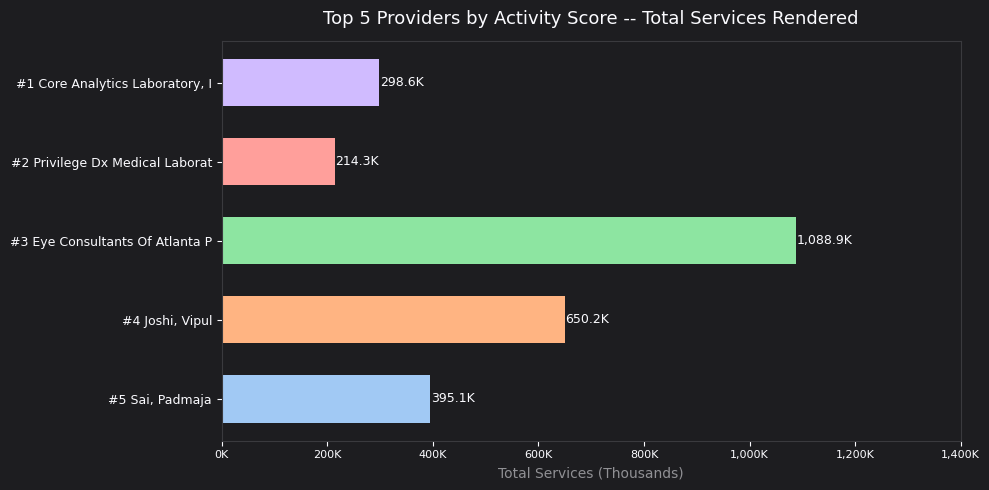

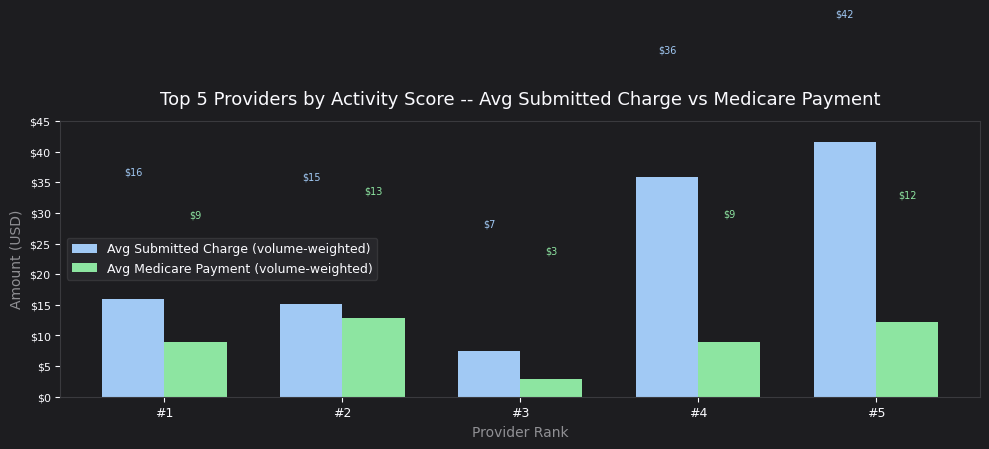

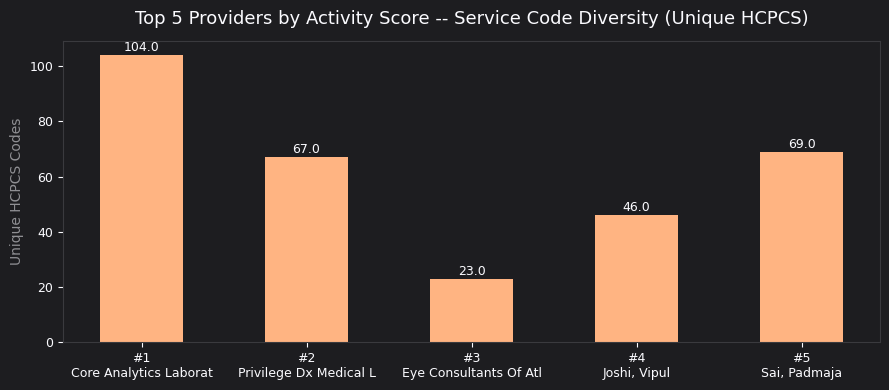

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Aggregate by provider ───────────────────────────────────────────────────
def _weighted_mean(df, value_col, weight_col):
    w = df[weight_col]
    return np.average(df[value_col], weights=w) if w.sum() > 0 else df[value_col].mean()

provider_agg = (
    claims_df
    .groupby(["npi", "provider_last_org_name", "provider_first_name",
              "provider_type", "provider_state"], as_index=False)
    .apply(lambda g: pd.Series({
        "total_services":       g["total_services"].sum(),
        "total_beneficiaries":  g["total_beneficiaries"].sum(),
        "avg_submitted_charge": _weighted_mean(g, "avg_submitted_charge", "total_services"),
        "avg_medicare_payment": _weighted_mean(g, "avg_medicare_payment_amt", "total_services"),
        "unique_hcpcs_codes":   g["hcpcs_code"].nunique(),
        "claim_lines":          g["hcpcs_code"].count(),
    }), include_groups=False)
    .reset_index()
)

# Composite activity score: normalise each metric 0-1 (true min-max), weight & sum
for col in ["total_services", "total_beneficiaries", "avg_submitted_charge", "claim_lines"]:
    _min, _max = provider_agg[col].min(), provider_agg[col].max()
    provider_agg[f"_{col}_norm"] = (provider_agg[col] - _min) / (_max - _min + 1e-9)

provider_agg["composite_score"] = (
    provider_agg["_total_services_norm"]        * 0.35 +
    provider_agg["_total_beneficiaries_norm"]   * 0.30 +
    provider_agg["_avg_submitted_charge_norm"]  * 0.20 +
    provider_agg["_claim_lines_norm"]           * 0.15
)

top5 = provider_agg.nlargest(5, "composite_score").reset_index(drop=True)
top5.index += 1  # rank 1-5

# Build display name
top5["provider_name"] = (
    top5["provider_last_org_name"].str.strip() + ", " +
    top5["provider_first_name"].str.strip()
).str.strip(", ")

print("=" * 70)
print("TOP 5 PROVIDERS -- COMPOSITE ACTIVITY SCORE (volume-based, not a fraud signal)")
print("=" * 70)
_display_cols = [
    "provider_name", "provider_type", "provider_state",
    "total_services", "total_beneficiaries",
    "avg_submitted_charge", "avg_medicare_payment",
    "unique_hcpcs_codes", "composite_score"
]
print(top5[_display_cols].to_string(
    index=True,
    float_format=lambda x: f"{x:,.2f}"
))

# ── Chart 1: Total Services ─────────────────────────────────────────────────
_labels  = [f"#{i} {n[:28]}" for i, n in zip(top5.index, top5["provider_name"])]
_services = top5["total_services"].values / 1_000  # thousands

fig_services, ax1 = plt.subplots(figsize=(10, 5))
fig_services.patch.set_facecolor("#1D1D20")
ax1.set_facecolor("#1D1D20")

_bars = ax1.barh(_labels[::-1], _services[::-1],
                 color=["#A1C9F4","#FFB482","#8DE5A1","#FF9F9B","#D0BBFF"],
                 edgecolor="none", height=0.6)

for bar, val in zip(_bars, _services[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:,.1f}K", va="center", ha="left",
             color="#fbfbff", fontsize=9)

ax1.set_xlabel("Total Services (Thousands)", color="#909094", fontsize=10)
ax1.set_title("Top 5 Providers by Activity Score -- Total Services Rendered",
              color="#fbfbff", fontsize=13, pad=12)
ax1.tick_params(colors="#fbfbff", labelsize=9)
ax1.xaxis.label.set_color("#909094")
for spine in ax1.spines.values():
    spine.set_edgecolor("#3a3a3e")
ax1.set_xlim(0, _services.max() * 1.18)

# pre-compute tick labels -- no FuncFormatter
_xticks = ax1.get_xticks()
ax1.set_xticks(_xticks)
ax1.set_xticklabels([f"{t:,.0f}K" for t in _xticks], color="#fbfbff", fontsize=8)

plt.tight_layout()
plt.show()

# ── Chart 2: Avg Submitted Charge vs Medicare Payment (volume-weighted) ─────
_x         = np.arange(5)
_bar_width  = 0.35
_charges    = top5["avg_submitted_charge"].values
_payments   = top5["avg_medicare_payment"].values
_short_lbls = [f"#{i}" for i in top5.index]

fig_charges, ax2 = plt.subplots(figsize=(10, 5))
fig_charges.patch.set_facecolor("#1D1D20")
ax2.set_facecolor("#1D1D20")

ax2.bar(_x - _bar_width/2, _charges, _bar_width,
        label="Avg Submitted Charge (volume-weighted)", color="#A1C9F4", edgecolor="none")
ax2.bar(_x + _bar_width/2, _payments, _bar_width,
        label="Avg Medicare Payment (volume-weighted)",  color="#8DE5A1", edgecolor="none")

ax2.set_xticks(_x)
ax2.set_xticklabels(_short_lbls, color="#fbfbff", fontsize=10)
ax2.set_xlabel("Provider Rank", color="#909094", fontsize=10)
ax2.set_ylabel("Amount (USD)",  color="#909094", fontsize=10)
ax2.set_title("Top 5 Providers by Activity Score -- Avg Submitted Charge vs Medicare Payment",
              color="#fbfbff", fontsize=13, pad=12)
ax2.tick_params(colors="#fbfbff", labelsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor("#3a3a3e")
ax2.legend(facecolor="#2a2a2e", edgecolor="#3a3a3e",
           labelcolor="#fbfbff", fontsize=9)

# pre-compute y tick labels
_yticks = ax2.get_yticks()
ax2.set_yticks(_yticks)
ax2.set_yticklabels([f"${t:,.0f}" for t in _yticks], color="#fbfbff", fontsize=8)

# annotate bars
for xpos, ch, py in zip(_x, _charges, _payments):
    ax2.text(xpos - _bar_width/2, ch + 20, f"${ch:,.0f}",
             ha="center", va="bottom", color="#A1C9F4", fontsize=7)
    ax2.text(xpos + _bar_width/2, py + 20, f"${py:,.0f}",
             ha="center", va="bottom", color="#8DE5A1", fontsize=7)

plt.tight_layout()
plt.show()

# ── Chart 3: Unique HCPCS codes (service diversity) ────────────────────────
fig_hcpcs, ax3 = plt.subplots(figsize=(9, 4))
fig_hcpcs.patch.set_facecolor("#1D1D20")
ax3.set_facecolor("#1D1D20")

_hcpcs = top5["unique_hcpcs_codes"].values

ax3.bar(_x, _hcpcs, color="#FFB482", edgecolor="none", width=0.5)
ax3.set_xticks(_x)
ax3.set_xticklabels(
    [f"#{i}\n{n[:22]}" for i, n in zip(top5.index, top5["provider_name"])],
    color="#fbfbff", fontsize=8
)
ax3.set_ylabel("Unique HCPCS Codes", color="#909094", fontsize=10)
ax3.set_title("Top 5 Providers by Activity Score -- Service Code Diversity (Unique HCPCS)",
              color="#fbfbff", fontsize=13, pad=12)
ax3.tick_params(colors="#fbfbff", labelsize=9)
for spine in ax3.spines.values():
    spine.set_edgecolor("#3a3a3e")

for xpos, val in zip(_x, _hcpcs):
    ax3.text(xpos, val + 0.3, str(val),
             ha="center", va="bottom", color="#fbfbff", fontsize=9)

plt.tight_layout()
plt.show()


# TOP 5 Provider Types by Composite Activity Score

*Same activity/volume score as above, applied at the specialty level. Volume-based, not a fraud signal.*


TOP 5 PROVIDER TYPES -- COMPOSITE ACTIVITY SCORE (volume-based, not a fraud signal)
                            provider_type  unique_providers  total_services  total_beneficiaries  avg_submitted_charge  avg_medicare_payment  unique_hcpcs  composite_score
1                    Diagnostic Radiology            319.00    2,328,791.00           793,546.00                112.64                 17.09        384.00             0.74
2                      Nurse Practitioner          1,820.00    2,328,883.00           512,574.00                101.85                 30.99        575.00             0.63
3                       Internal Medicine            934.00    1,385,925.50           604,052.00                272.94                131.70        465.00             0.57
4  Physical Therapist in Private Practice            759.00    1,752,336.00           203,570.00                 71.63                 19.95         39.00             0.48
5                         Family Practice            815

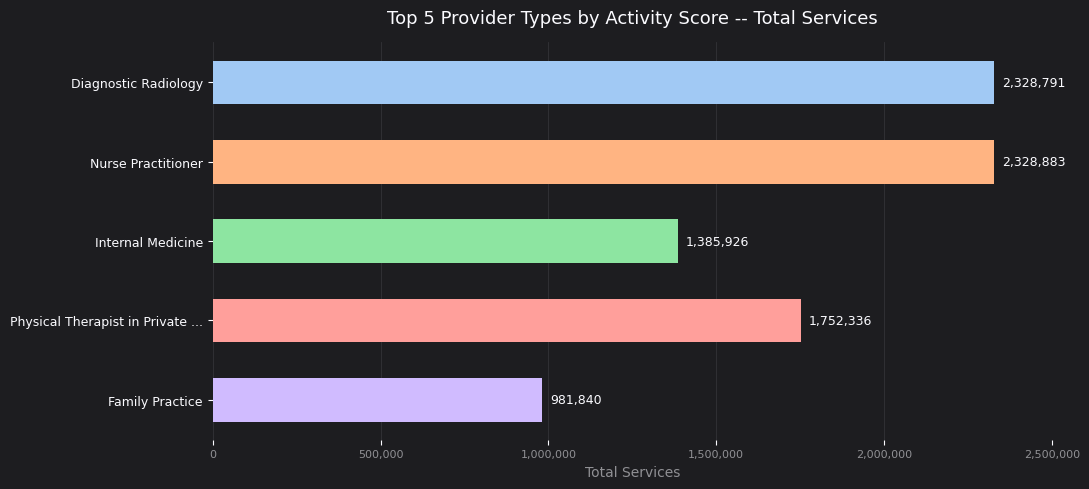

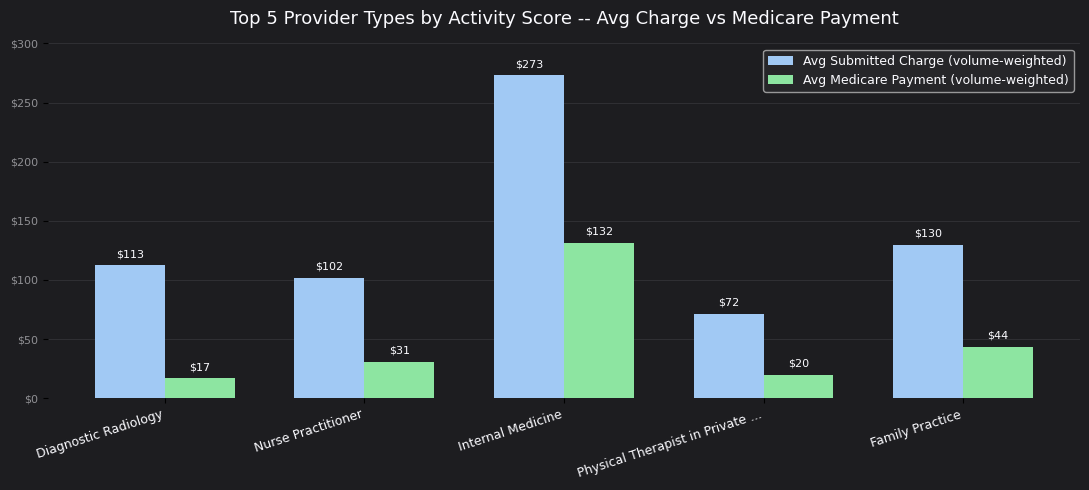

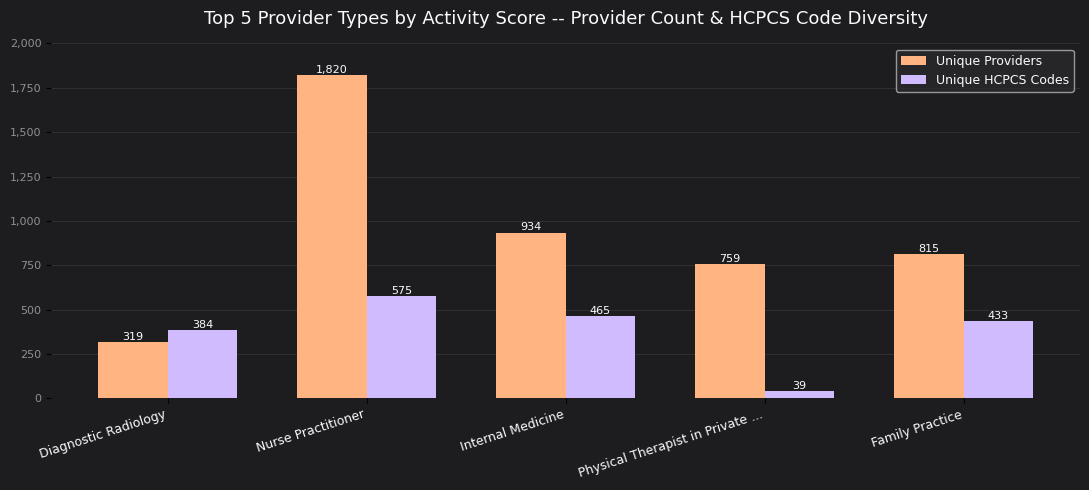



Note: composite activity score ranks by volume only (services, beneficiaries,
charge, claim lines). It does not measure anomalousness -- see the peer-adjusted
fraud flags in the 'Fraud Detection - Risk Flags' section for that.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Aggregate by provider_type ───────────────────────────────────────────────
def _weighted_mean(df, value_col, weight_col):
    w = df[weight_col]
    return np.average(df[value_col], weights=w) if w.sum() > 0 else df[value_col].mean()

type_agg = (
    claims_df.groupby("provider_type")
    .apply(lambda g: pd.Series({
        "unique_providers":     g["npi"].nunique(),
        "total_services":       g["total_services"].sum(),
        "total_beneficiaries":  g["total_beneficiaries"].sum(),
        "total_claim_lines":    g["total_beneficiary_day_services"].sum(),
        "avg_submitted_charge": _weighted_mean(g, "avg_submitted_charge", "total_services"),
        "avg_medicare_payment": _weighted_mean(g, "avg_medicare_payment_amt", "total_services"),
        "avg_medicare_allowed": _weighted_mean(g, "avg_medicare_allowed_amt", "total_services"),
        "unique_hcpcs":         g["hcpcs_code"].nunique(),
    }), include_groups=False)
    .reset_index()
)

# ── Composite activity score (same weights AND same true min-max normalisation
#    as the provider-level analysis in the previous cell) ────────────────────
for col in ["total_services", "total_beneficiaries", "avg_submitted_charge", "total_claim_lines"]:
    _min, _max = type_agg[col].min(), type_agg[col].max()
    type_agg[f"_{col}_norm"] = (type_agg[col] - _min) / (_max - _min + 1e-9)

type_agg["composite_score"] = (
    0.35 * type_agg["_total_services_norm"] +
    0.30 * type_agg["_total_beneficiaries_norm"] +
    0.20 * type_agg["_avg_submitted_charge_norm"] +
    0.15 * type_agg["_total_claim_lines_norm"]
)

top5_types = type_agg.nlargest(5, "composite_score").reset_index(drop=True)
top5_types.index += 1

# ── Print summary table ──────────────────────────────────────────────────────
print("=" * 80)
print("TOP 5 PROVIDER TYPES -- COMPOSITE ACTIVITY SCORE (volume-based, not a fraud signal)")
print("=" * 80)
_display_cols = [
    "provider_type", "unique_providers", "total_services",
    "total_beneficiaries", "avg_submitted_charge",
    "avg_medicare_payment", "unique_hcpcs", "composite_score"
]
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
print(top5_types[_display_cols].to_string())

# charge-to-payment ratio
top5_types["charge_payment_ratio"] = (
    top5_types["avg_submitted_charge"] / top5_types["avg_medicare_payment"].replace(0, np.nan)
)

print("\n\nCHARGE-TO-PAYMENT RATIO (avg submitted / avg medicare payment, volume-weighted)")
print("-" * 60)
for _, row in top5_types.iterrows():
    print(f"  {row['provider_type']:<40}  {row['charge_payment_ratio']:>6.2f}x")

# ── Colour palette ───────────────────────────────────────────────────────────
COLORS  = ["#A1C9F4", "#FFB482", "#8DE5A1", "#FF9F9B", "#D0BBFF"]
BG      = "#1D1D20"
TXT     = "#fbfbff"
TXT2    = "#909094"
_labels = [t[:30] + "..." if len(t) > 30 else t for t in top5_types["provider_type"]]

# ── Chart 1: Total Services ───────────────────────────────────────────────────
fig_type_services, ax = plt.subplots(figsize=(11, 5))
fig_type_services.patch.set_facecolor(BG)
ax.set_facecolor(BG)

_bars = ax.barh(_labels[::-1], top5_types["total_services"].values[::-1],
                color=COLORS[::-1], edgecolor="none", height=0.55)
for bar in _bars:
    _w = bar.get_width()
    ax.text(_w + top5_types["total_services"].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{_w:,.0f}", va="center", ha="left", color=TXT, fontsize=9)

ax.set_xlabel("Total Services", color=TXT2, fontsize=10)
ax.set_title("Top 5 Provider Types by Activity Score -- Total Services", color=TXT, fontsize=13, pad=14)
ax.tick_params(colors=TXT, labelsize=9)
ax.xaxis.label.set_color(TXT2)
_xticks = [int(v) for v in ax.get_xticks()]
ax.set_xticks(_xticks)
ax.set_xticklabels([f"{int(v):,}" for v in _xticks], color=TXT2, fontsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, color="#333337", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Chart 2: Avg Submitted Charge vs Medicare Payment (volume-weighted) ─────
fig_type_charges, ax2 = plt.subplots(figsize=(11, 5))
fig_type_charges.patch.set_facecolor(BG)
ax2.set_facecolor(BG)

_x     = np.arange(len(top5_types))
_w     = 0.35
_ch    = ax2.bar(_x - _w/2, top5_types["avg_submitted_charge"], _w,
                 label="Avg Submitted Charge (volume-weighted)", color="#A1C9F4", edgecolor="none")
_py    = ax2.bar(_x + _w/2, top5_types["avg_medicare_payment"], _w,
                 label="Avg Medicare Payment (volume-weighted)", color="#8DE5A1", edgecolor="none")

for bar in list(_ch) + list(_py):
    _h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, _h + 5,
             f"${_h:,.0f}", ha="center", va="bottom", color=TXT, fontsize=8)

ax2.set_xticks(_x)
ax2.set_xticklabels(_labels, rotation=18, ha="right", color=TXT, fontsize=9)
_yticks = [int(v) for v in ax2.get_yticks()]
ax2.set_yticks(_yticks)
ax2.set_yticklabels([f"${int(v):,}" for v in _yticks], color=TXT2, fontsize=8)
ax2.set_title("Top 5 Provider Types by Activity Score -- Avg Charge vs Medicare Payment", color=TXT, fontsize=13, pad=14)
ax2.legend(facecolor="#2a2a2e", labelcolor=TXT, fontsize=9, framealpha=0.7)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.yaxis.grid(True, color="#333337", linewidth=0.6)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Chart 3: Unique Providers & HCPCS Code Diversity ─────────────────────────
fig_type_diversity, ax3 = plt.subplots(figsize=(11, 5))
fig_type_diversity.patch.set_facecolor(BG)
ax3.set_facecolor(BG)

_x2  = np.arange(len(top5_types))
_b1  = ax3.bar(_x2 - _w/2, top5_types["unique_providers"], _w,
               label="Unique Providers", color="#FFB482", edgecolor="none")
_b2  = ax3.bar(_x2 + _w/2, top5_types["unique_hcpcs"], _w,
               label="Unique HCPCS Codes", color="#D0BBFF", edgecolor="none")

for bar in list(_b1) + list(_b2):
    _h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, _h + 0.5,
             f"{int(_h):,}", ha="center", va="bottom", color=TXT, fontsize=8)

ax3.set_xticks(_x2)
ax3.set_xticklabels(_labels, rotation=18, ha="right", color=TXT, fontsize=9)
_yticks3 = [int(v) for v in ax3.get_yticks()]
ax3.set_yticks(_yticks3)
ax3.set_yticklabels([f"{int(v):,}" for v in _yticks3], color=TXT2, fontsize=8)
ax3.set_title("Top 5 Provider Types by Activity Score -- Provider Count & HCPCS Code Diversity", color=TXT, fontsize=13, pad=14)
ax3.legend(facecolor="#2a2a2e", labelcolor=TXT, fontsize=9, framealpha=0.7)
for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.yaxis.grid(True, color="#333337", linewidth=0.6)
ax3.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("\n\nNote: composite activity score ranks by volume only (services, beneficiaries,")
print("charge, claim lines). It does not measure anomalousness -- see the peer-adjusted")
print("fraud flags in the 'Fraud Detection - Risk Flags' section for that.")


# EDA - TOP 10 Provider Type by Total Services

/var/folders/1w/gdlbhzx57wn489ztk0lds0l40000gn/T/ipykernel_95507/2664701745.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(_type_services["provider_type"], color=TXT, fontsize=10)


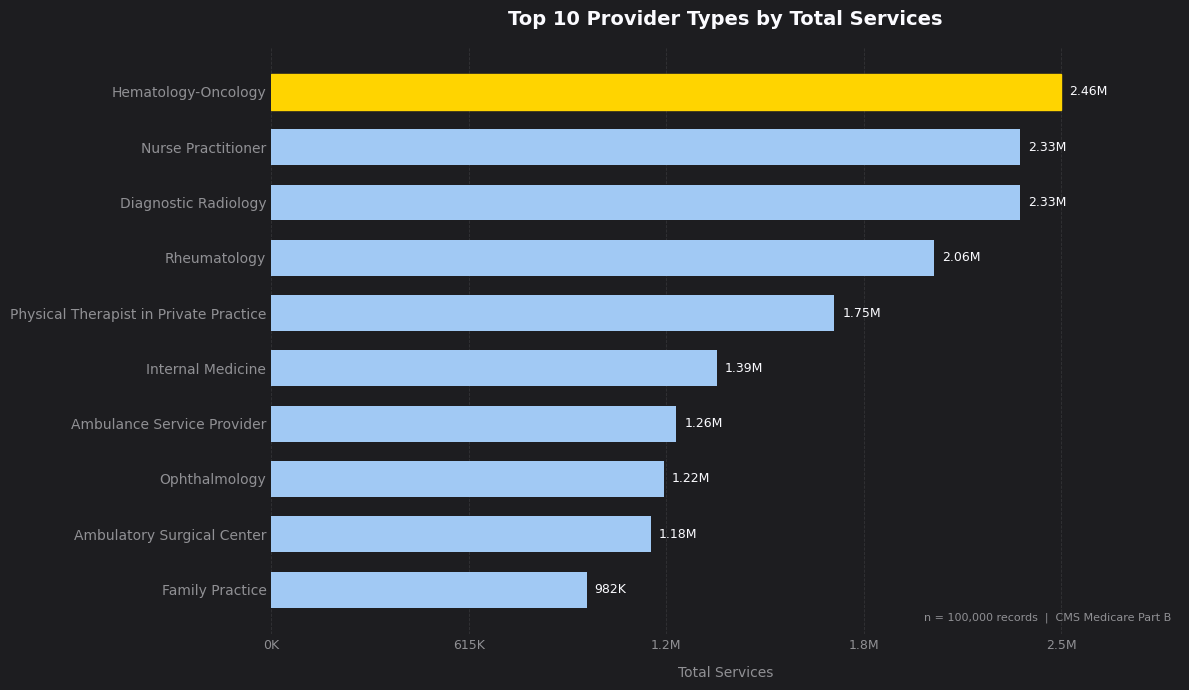

Top 10 Provider Types by Total Services:
                         provider_type  total_services
                   Hematology-Oncology    2,458,540.00
                    Nurse Practitioner    2,328,883.00
                  Diagnostic Radiology    2,328,791.00
                          Rheumatology    2,061,715.30
Physical Therapist in Private Practice    1,752,336.00
                     Internal Medicine    1,385,925.50
            Ambulance Service Provider    1,260,132.80
                         Ophthalmology    1,220,658.00
            Ambulatory Surgical Center    1,181,122.00
                       Family Practice      981,840.00


In [23]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BG  = "#1D1D20"
TXT = "#fbfbff"
TXT2 = "#909094"
BAR_COLOR = "#A1C9F4"
ACCENT = "#ffd400"

# Aggregate total services by provider type
_type_services = (
    claims_df.groupby("provider_type")["total_services"]
    .sum()
    .reset_index()
    .sort_values("total_services", ascending=False)
    .head(10)
    .sort_values("total_services", ascending=True)  # ascending for horizontal bar readability
)

fig_top10_type_services, ax = plt.subplots(figsize=(12, 7))
fig_top10_type_services.patch.set_facecolor(BG)
ax.set_facecolor(BG)

_bars = ax.barh(
    _type_services["provider_type"],
    _type_services["total_services"],
    color=BAR_COLOR,
    height=0.65,
    edgecolor="none"
)

# Highlight top bar
_bars[-1].set_color(ACCENT)

# Value labels
for _bar in _bars:
    _w = _bar.get_width()
    _label = f"{_w/1_000_000:.2f}M" if _w >= 1_000_000 else f"{_w/1_000:.0f}K"
    ax.text(
        _w + _type_services["total_services"].max() * 0.01,
        _bar.get_y() + _bar.get_height() / 2,
        _label,
        va="center", ha="left", color=TXT, fontsize=9
    )

# Axis styling
_max_val = _type_services["total_services"].max()
_xticks = np.linspace(0, _max_val, 5)
_xlabels = [f"{v/1_000_000:.1f}M" if v >= 1_000_000 else f"{v/1_000:.0f}K" for v in _xticks]
ax.set_xticks(_xticks)
ax.set_xticklabels(_xlabels, color=TXT2, fontsize=9)
ax.set_yticklabels(_type_services["provider_type"], color=TXT, fontsize=10)
ax.set_xlim(0, _max_val * 1.15)

ax.set_title("Top 10 Provider Types by Total Services", color=TXT, fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Total Services", color=TXT2, fontsize=10, labelpad=10)
ax.tick_params(colors=TXT2, length=0)

for _spine in ax.spines.values():
    _spine.set_visible(False)
ax.xaxis.grid(True, color="#333336", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.text(
    0.99, 0.02,
    f"n = {claims_df.shape[0]:,} records  |  CMS Medicare Part B",
    transform=ax.transAxes, ha="right", va="bottom",
    color=TXT2, fontsize=8
)

plt.tight_layout()
plt.show()

print("Top 10 Provider Types by Total Services:")
print(_type_services[["provider_type","total_services"]].sort_values("total_services", ascending=False).to_string(index=False))


# EDA - TOP 10 States by Average Submitted Charge

/var/folders/1w/gdlbhzx57wn489ztk0lds0l40000gn/T/ipykernel_95507/1915857166.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(_state_charge["provider_state"], color=TXT, fontsize=11)


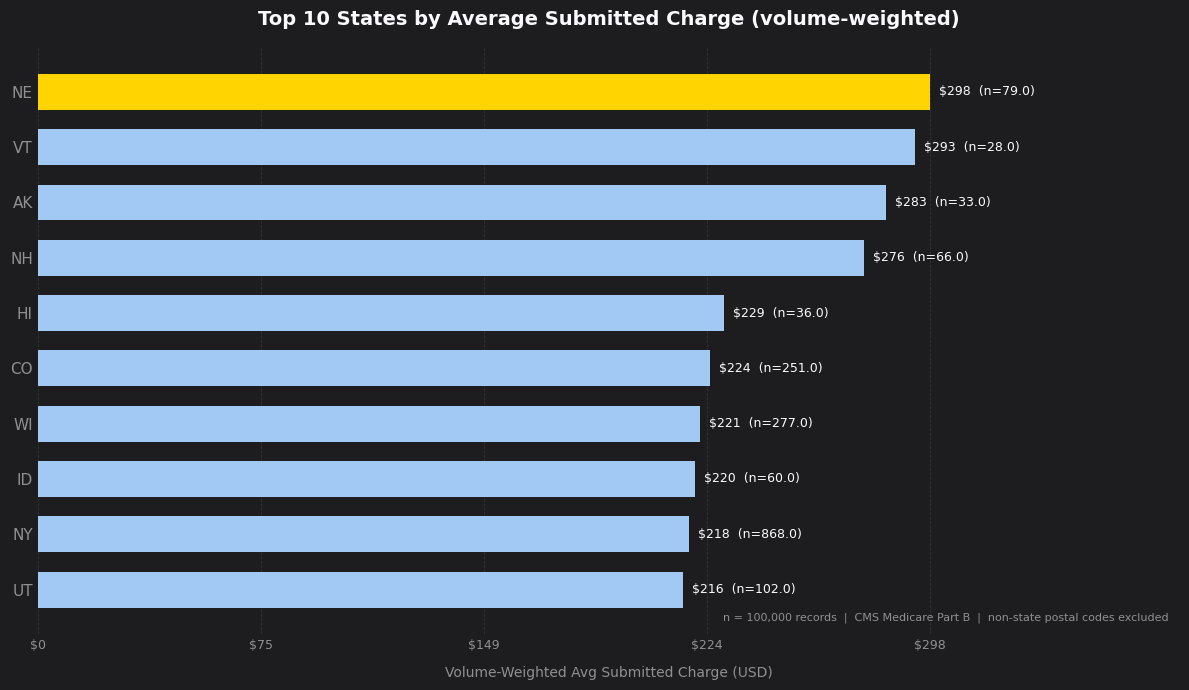

Top 10 States by Average Submitted Charge (volume-weighted, non-state codes excluded):
provider_state  mean_submitted_charge  n_records  n_providers
            NE                 298.11     813.00        79.00
            VT                 293.20     162.00        28.00
            AK                 283.48     168.00        33.00
            NH                 276.00     533.00        66.00
            HI                 229.27     197.00        36.00
            CO                 224.47   1,790.00       251.00
            WI                 221.28   1,763.00       277.00
            ID                 219.61     455.00        60.00
            NY                 217.57   6,601.00       868.00
            UT                 215.55     867.00       102.00


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BG   = "#1D1D20"
TXT  = "#fbfbff"
TXT2 = "#909094"
ACCENT = "#ffd400"

# Exclude non-US-state/territory postal codes (e.g. "AE" = Armed Forces Europe,
# "AA"/"AP" = other military postal codes) so a handful of low-volume records
# can't masquerade as a geographic "state" hotspot. See the Data Quality
# Investigation cell above for why this exclusion is warranted.
_NON_STATE_CODES = {"AA", "AE", "AP"}
_state_df = claims_df[~claims_df["provider_state"].isin(_NON_STATE_CODES)]

# Aggregate avg submitted charge by state, weighted by total_services so a
# state with many low-volume line items isn't diluted equally with one that
# has a few extremely high-volume ones (fixes mean-of-means distortion).
def _weighted_mean(g):
    w = g["total_services"]
    return np.average(g["avg_submitted_charge"], weights=w) if w.sum() > 0 else g["avg_submitted_charge"].mean()

_state_charge = (
    _state_df.groupby("provider_state")
    .apply(lambda g: pd.Series({
        "mean_submitted_charge": _weighted_mean(g),
        "n_records": len(g),
        "n_providers": g["npi"].nunique(),
    }), include_groups=False)
    .reset_index()
    .sort_values("mean_submitted_charge", ascending=False)
    .head(10)
    .sort_values("mean_submitted_charge", ascending=True)
)

# Palette: gradient from blue to gold for top state
_n = len(_state_charge)
_palette = ["#A1C9F4"] * _n
_palette[-1] = ACCENT  # highlight top state

fig_top10_state_charge, ax = plt.subplots(figsize=(12, 7))
fig_top10_state_charge.patch.set_facecolor(BG)
ax.set_facecolor(BG)

_bars = ax.barh(
    _state_charge["provider_state"],
    _state_charge["mean_submitted_charge"],
    color=_palette,
    height=0.65,
    edgecolor="none"
)

# Value labels, annotated with sample size (n providers) so small-n entries
# are visibly distinguishable from high-confidence, large-sample states.
for _bar, (_, _row) in zip(_bars, _state_charge.iterrows()):
    _w = _bar.get_width()
    ax.text(
        _w + _state_charge["mean_submitted_charge"].max() * 0.01,
        _bar.get_y() + _bar.get_height() / 2,
        f"${_w:,.0f}  (n={_row['n_providers']:,})",
        va="center", ha="left", color=TXT, fontsize=9
    )

# X-axis ticks
_max_val = _state_charge["mean_submitted_charge"].max()
_xticks = np.linspace(0, _max_val, 5)
_xlabels = [f"${v:,.0f}" for v in _xticks]
ax.set_xticks(_xticks)
ax.set_xticklabels(_xlabels, color=TXT2, fontsize=9)
ax.set_yticklabels(_state_charge["provider_state"], color=TXT, fontsize=11)
ax.set_xlim(0, _max_val * 1.28)

ax.set_title("Top 10 States by Average Submitted Charge (volume-weighted)", color=TXT, fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Volume-Weighted Avg Submitted Charge (USD)", color=TXT2, fontsize=10, labelpad=10)
ax.tick_params(colors=TXT2, length=0)

for _spine in ax.spines.values():
    _spine.set_visible(False)
ax.xaxis.grid(True, color="#333336", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.text(
    0.99, 0.02,
    f"n = {claims_df.shape[0]:,} records  |  CMS Medicare Part B  |  non-state postal codes excluded",
    transform=ax.transAxes, ha="right", va="bottom",
    color=TXT2, fontsize=8
)

plt.tight_layout()
plt.show()

print("Top 10 States by Average Submitted Charge (volume-weighted, non-state codes excluded):")
print(_state_charge[["provider_state", "mean_submitted_charge", "n_records", "n_providers"]]
      .sort_values("mean_submitted_charge", ascending=False).to_string(index=False))


# EDA - Average Submitted Charge vs Average Medicare Payment by Place of Service 

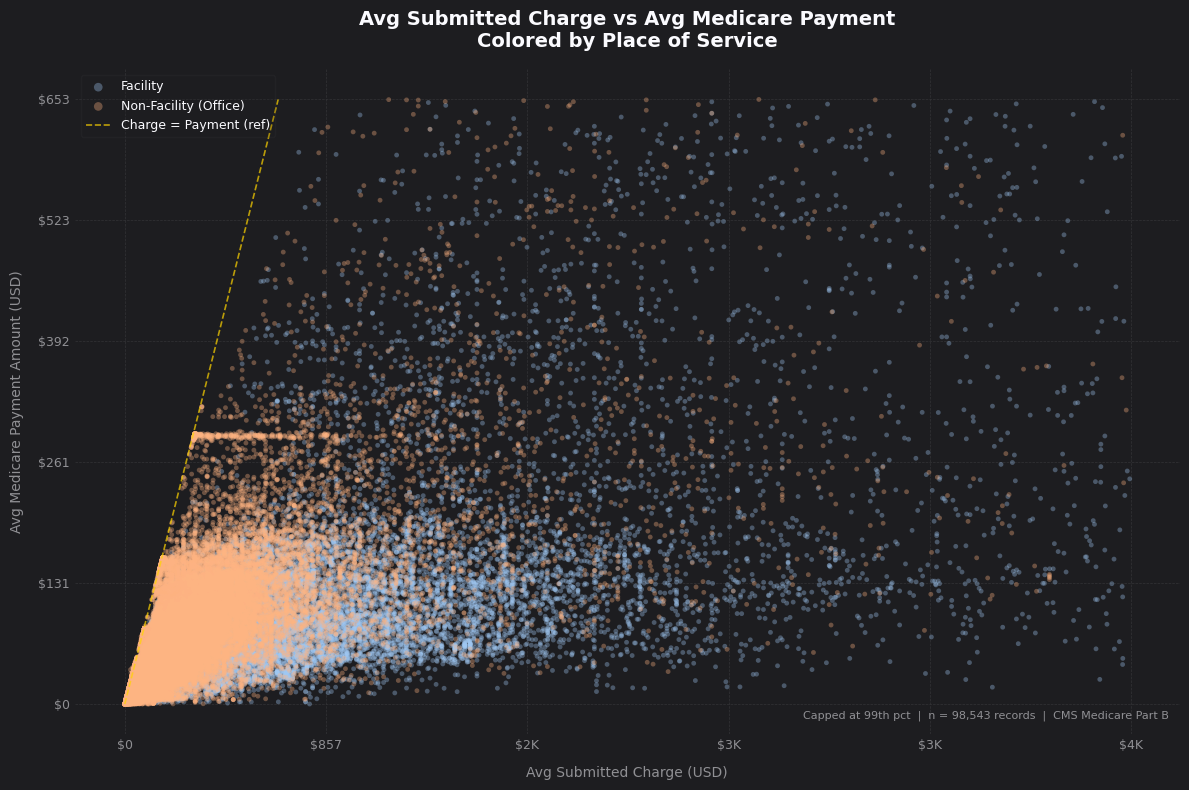

Scatter Summary — Avg Charge vs Avg Payment by Place of Service:
                       records  mean_charge  mean_payment  payment_ratio
pos_label                                                               
Facility                 34465       511.01         78.47           0.15
Non-Facility (Office)    64078       221.01         60.56           0.27


In [25]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG   = "#1D1D20"
TXT  = "#fbfbff"
TXT2 = "#909094"

# Map place_of_service codes to readable labels
_pos_map = {"F": "Facility", "O": "Non-Facility (Office)"}
_plot_df = claims_df.copy()
_plot_df["pos_label"] = _plot_df["place_of_service"].map(_pos_map).fillna("Other")

# Cap extreme outliers at 99th percentile for visual clarity
_cap_x = _plot_df["avg_submitted_charge"].quantile(0.99)
_cap_y = _plot_df["avg_medicare_payment_amt"].quantile(0.99)
_plot_df = _plot_df[
    (_plot_df["avg_submitted_charge"] <= _cap_x) &
    (_plot_df["avg_medicare_payment_amt"] <= _cap_y)
]

_color_map = {
    "Facility":              "#A1C9F4",   # light blue
    "Non-Facility (Office)": "#FFB482",   # orange
    "Other":                 "#8DE5A1",   # green
}

fig_scatter_pos, ax = plt.subplots(figsize=(12, 8))
fig_scatter_pos.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for _pos, _grp in _plot_df.groupby("pos_label"):
    ax.scatter(
        _grp["avg_submitted_charge"],
        _grp["avg_medicare_payment_amt"],
        c=_color_map.get(_pos, "#D0BBFF"),
        alpha=0.35,
        s=12,
        edgecolors="none",
        label=_pos,
        rasterized=True
    )

# y = x reference line (submitted == paid — perfect alignment)
_ref_max = min(_cap_x, _cap_y)
ax.plot([0, _ref_max], [0, _ref_max], color="#ffd400", linewidth=1.2,
        linestyle="--", alpha=0.7, label="Charge = Payment (ref)")

# Axis ticks — pre-computed string labels
_xtick_vals = np.linspace(0, _cap_x, 6)
_ytick_vals = np.linspace(0, _cap_y, 6)
_xlabels = [f"${v/1000:.0f}K" if v >= 1000 else f"${v:.0f}" for v in _xtick_vals]
_ylabels = [f"${v/1000:.0f}K" if v >= 1000 else f"${v:.0f}" for v in _ytick_vals]

ax.set_xticks(_xtick_vals)
ax.set_xticklabels(_xlabels, color=TXT2, fontsize=9)
ax.set_yticks(_ytick_vals)
ax.set_yticklabels(_ylabels, color=TXT2, fontsize=9)

ax.set_title(
    "Avg Submitted Charge vs Avg Medicare Payment\nColored by Place of Service",
    color=TXT, fontsize=14, fontweight="bold", pad=16
)
ax.set_xlabel("Avg Submitted Charge (USD)", color=TXT2, fontsize=10, labelpad=10)
ax.set_ylabel("Avg Medicare Payment Amount (USD)", color=TXT2, fontsize=10, labelpad=10)
ax.tick_params(colors=TXT2, length=0)

for _spine in ax.spines.values():
    _spine.set_visible(False)
ax.grid(True, color="#333336", linewidth=0.5, linestyle="--")
ax.set_axisbelow(True)

_legend = ax.legend(
    frameon=True, framealpha=0.15, facecolor=BG, edgecolor="#444448",
    labelcolor=TXT, fontsize=9, loc="upper left", markerscale=1.8
)

ax.text(
    0.99, 0.02,
    f"Capped at 99th pct  |  n = {len(_plot_df):,} records  |  CMS Medicare Part B",
    transform=ax.transAxes, ha="right", va="bottom",
    color=TXT2, fontsize=8
)

plt.tight_layout()
plt.show()

# Summary stats by place of service
_summary = (
    _plot_df.groupby("pos_label")
    .agg(
        records=("avg_submitted_charge", "count"),
        mean_charge=("avg_submitted_charge", "mean"),
        mean_payment=("avg_medicare_payment_amt", "mean"),
    )
    .assign(payment_ratio=lambda d: d["mean_payment"] / d["mean_charge"])
    .round(2)
)
print("Scatter Summary — Avg Charge vs Avg Payment by Place of Service:")
print(_summary.to_string())


# Fraud Detection - Risk Flags

In [26]:
import pandas as pd
import numpy as np

# ── Feature Engineering ────────────────────────────────────────────────────────

fraud_df = claims_df.copy()

# 1. Charge-to-payment ratio (guard against division by zero)
fraud_df['charge_payment_ratio'] = np.where(
    fraud_df['avg_medicare_payment_amt'] > 0,
    fraud_df['avg_submitted_charge'] / fraud_df['avg_medicare_payment_amt'],
    np.nan
)

# 2. Services per beneficiary
fraud_df['services_per_beneficiary'] = np.where(
    fraud_df['total_beneficiaries'] > 0,
    fraud_df['total_services'] / fraud_df['total_beneficiaries'],
    np.nan
)

# ── Global Thresholds ──────────────────────────────────────────────────────────

ratio_median    = fraud_df['charge_payment_ratio'].median()
ratio_threshold = ratio_median * 3

# 99th percentile as high-utilization threshold
spb_threshold = fraud_df['services_per_beneficiary'].quantile(0.99)

print(f"Charge-to-Payment Ratio  -- Median           : {ratio_median:.2f}")
print(f"Charge-to-Payment Ratio  -- Threshold (3x)   : {ratio_threshold:.2f}")
print(f"Services per Beneficiary -- 99th Percentile  : {spb_threshold:.2f}")

# ── Global Risk Labels ─────────────────────────────────────────────────────────

fraud_df['potential_fraud'] = np.where(
    fraud_df['charge_payment_ratio'] > ratio_threshold,
    'High Risk',
    'Normal'
)

fraud_df['utilization_flag'] = np.where(
    fraud_df['services_per_beneficiary'] > spb_threshold,
    'High Utilization',
    'Normal'
)

# ── Peer-group (specialty) z-scores ────────────────────────────────────────────
# A global threshold treats a Hematology-Oncology provider (naturally high-cost
# drug administration billing) the same as a Family Practice provider. Here we
# additionally compute each provider's ratio/SPB as a z-score relative to its
# own provider_type peers, so specialty-driven baseline differences don't get
# mistaken for anomalous behavior. Specialties with too few providers (<30) for
# a stable std fall back to the global mean/std.
_MIN_PEER_N = 30

def _peer_zscore(df, col):
    _grp = df.groupby('provider_type')[col]
    _peer_mean = _grp.transform('mean')
    _peer_std  = _grp.transform('std')
    _peer_n    = _grp.transform('count')
    _global_mean = df[col].mean()
    _global_std  = df[col].std()
    _mean = np.where(_peer_n >= _MIN_PEER_N, _peer_mean, _global_mean)
    _std  = np.where((_peer_n >= _MIN_PEER_N) & (_peer_std > 0), _peer_std, _global_std)
    return (df[col] - _mean) / _std

fraud_df['charge_ratio_zscore_peer'] = _peer_zscore(fraud_df, 'charge_payment_ratio')
fraud_df['spb_zscore_peer']          = _peer_zscore(fraud_df, 'services_per_beneficiary')

fraud_df['potential_fraud_peer'] = np.where(
    fraud_df['charge_ratio_zscore_peer'] > 2,
    'High Risk (Peer)',
    'Normal'
)
fraud_df['utilization_flag_peer'] = np.where(
    fraud_df['spb_zscore_peer'] > 2,
    'High Utilization (Peer)',
    'Normal'
)

# ── Summary ────────────────────────────────────────────────────────────────────

total        = len(fraud_df)
high_risk    = (fraud_df['potential_fraud'] == 'High Risk').sum()
high_util    = (fraud_df['utilization_flag'] == 'High Utilization').sum()
both_flagged = ((fraud_df['potential_fraud'] == 'High Risk') &
                (fraud_df['utilization_flag'] == 'High Utilization')).sum()

high_risk_peer = (fraud_df['potential_fraud_peer'] == 'High Risk (Peer)').sum()
high_util_peer = (fraud_df['utilization_flag_peer'] == 'High Utilization (Peer)').sum()

print("\n" + "="*60)
print("RISK FLAG SUMMARY -- GLOBAL THRESHOLD")
print("="*60)
print(f"  Total rows              : {total:,}")
print(f"  High Risk (ratio)       : {high_risk:,}  ({high_risk/total*100:.1f}%)")
print(f"  High Utilization (SPB)  : {high_util:,}  ({high_util/total*100:.1f}%)")
print(f"  BOTH flags triggered    : {both_flagged:,}  ({both_flagged/total*100:.1f}%)")
print("="*60)

print("\n" + "="*60)
print("RISK FLAG SUMMARY -- SPECIALTY-RELATIVE (PEER Z-SCORE > 2)")
print("="*60)
print(f"  High Risk (Peer)        : {high_risk_peer:,}  ({high_risk_peer/total*100:.1f}%)")
print(f"  High Utilization (Peer) : {high_util_peer:,}  ({high_util_peer/total*100:.1f}%)")
print("="*60)

# ── Top 20 — Both Flags Triggered (global) ────────────────────────────────────

_both_mask = (
    (fraud_df['potential_fraud'] == 'High Risk') &
    (fraud_df['utilization_flag'] == 'High Utilization')
)

_display_cols = [
    'npi', 'provider_last_org_name', 'provider_first_name',
    'provider_type', 'provider_state',
    'avg_submitted_charge', 'avg_medicare_payment_amt',
    'charge_payment_ratio', 'total_services',
    'total_beneficiaries', 'services_per_beneficiary',
    'potential_fraud', 'utilization_flag'
]

top20_fraud = (
    fraud_df[_both_mask][_display_cols]
    .sort_values('charge_payment_ratio', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20_fraud.index += 1  # 1-based rank

print(f"\nTOP 20 ROWS -- BOTH GLOBAL FLAGS TRIGGERED (sorted by charge_payment_ratio desc)\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)
print(top20_fraud.to_string())


Charge-to-Payment Ratio  -- Median           : 3.86
Charge-to-Payment Ratio  -- Threshold (3x)   : 11.58
Services per Beneficiary -- 99th Percentile  : 60.71

RISK FLAG SUMMARY -- GLOBAL THRESHOLD
  Total rows              : 100,000
  High Risk (ratio)       : 8,084  (8.1%)
  High Utilization (SPB)  : 1,000  (1.0%)
  BOTH flags triggered    : 159  (0.2%)

RISK FLAG SUMMARY -- SPECIALTY-RELATIVE (PEER Z-SCORE > 2)
  High Risk (Peer)        : 1,919  (1.9%)
  High Utilization (Peer) : 1,433  (1.4%)

TOP 20 ROWS -- BOTH GLOBAL FLAGS TRIGGERED (sorted by charge_payment_ratio desc)

           npi provider_last_org_name provider_first_name         provider_type provider_state  avg_submitted_charge  avg_medicare_payment_amt  charge_payment_ratio  total_services  total_beneficiaries  services_per_beneficiary potential_fraud  utilization_flag
1   1003182106                   Igid               Henry   Hematology-Oncology             NV                 36.00                      0.05            

# Fraud Detection - Global vs Specialty-Relative (Peer) Flags


GLOBAL vs PEER (SPECIALTY-RELATIVE) HIGH-RISK FLAGGING
  Flagged by GLOBAL threshold only  : 6,601
  Flagged by PEER z-score only      : 436
  Flagged by BOTH methods           : 1,483

Rows flagged by the global rule but NOT the peer rule are typically in naturally high-cost specialties (e.g. oncology) where a high ratio is normal for the peer group -- likely false positives under a one-size-fits-all threshold. Rows flagged only by the peer rule are providers who are unusual *relative to their own specialty* even though their raw ratio isn't extreme globally -- these would be missed entirely by the global-only approach.


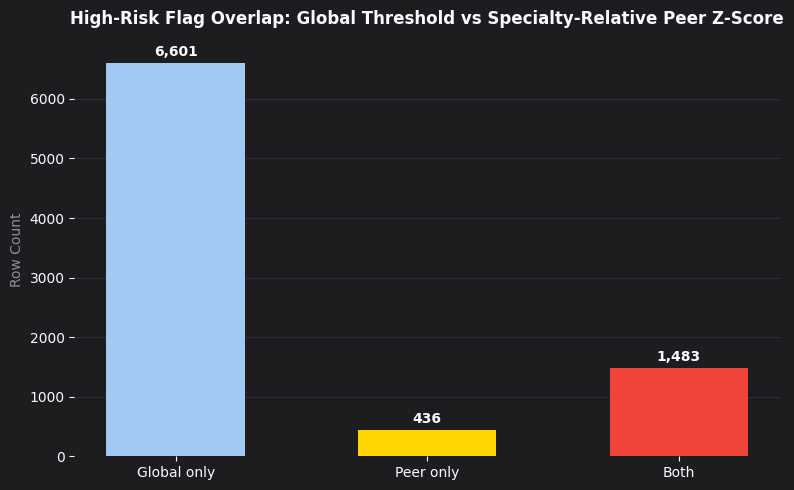

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BG   = "#1D1D20"
TXT  = "#fbfbff"
TXT2 = "#909094"
BLUE = "#A1C9F4"
GOLD = "#ffd400"

# How many providers/rows flip status once flagging is done relative to their
# own specialty (peer group) instead of one global threshold? This directly
# addresses the oncology-vs-family-practice confound noted in the project
# README's own Limitations section.
_global_risk = set(fraud_df.index[fraud_df["potential_fraud"] == "High Risk"])
_peer_risk   = set(fraud_df.index[fraud_df["potential_fraud_peer"] == "High Risk (Peer)"])

_only_global = len(_global_risk - _peer_risk)
_only_peer   = len(_peer_risk - _global_risk)
_both        = len(_global_risk & _peer_risk)

print("=" * 60)
print("GLOBAL vs PEER (SPECIALTY-RELATIVE) HIGH-RISK FLAGGING")
print("=" * 60)
print(f"  Flagged by GLOBAL threshold only  : {_only_global:,}")
print(f"  Flagged by PEER z-score only      : {_only_peer:,}")
print(f"  Flagged by BOTH methods           : {_both:,}")
print("=" * 60)
print(
    "\nRows flagged by the global rule but NOT the peer rule are typically in "
    "naturally high-cost specialties (e.g. oncology) where a high ratio is normal "
    "for the peer group -- likely false positives under a one-size-fits-all "
    "threshold. Rows flagged only by the peer rule are providers who are unusual "
    "*relative to their own specialty* even though their raw ratio isn't extreme "
    "globally -- these would be missed entirely by the global-only approach."
)

fig_compare, ax = plt.subplots(figsize=(8, 5))
fig_compare.patch.set_facecolor(BG)
ax.set_facecolor(BG)

_cats   = ["Global only", "Peer only", "Both"]
_counts = [_only_global, _only_peer, _both]
_colors = [BLUE, GOLD, "#f04438"]

_bars = ax.bar(_cats, _counts, color=_colors, edgecolor="none", width=0.55, zorder=2)
for _bar, _val in zip(_bars, _counts):
    ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + max(_counts) * 0.01,
            f"{_val:,}", ha="center", va="bottom", color=TXT, fontsize=10, fontweight="bold")

ax.set_title("High-Risk Flag Overlap: Global Threshold vs Specialty-Relative Peer Z-Score",
             color=TXT, fontsize=12, fontweight="bold", pad=14)
ax.set_ylabel("Row Count", color=TXT2, fontsize=10)
ax.tick_params(colors=TXT, labelsize=10)
ax.yaxis.grid(True, color="#333337", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


# Fraud Vizualization - Charge Payment Ratio by Place of Service

Charge-Payment Ratio by Place of Service (capped at P99 = 33.82):
                          count  mean  std  min  25%  50%  75%   max
pos_label                                                           
Facility              35,124.00  6.84 5.34 1.02 3.50 4.97 8.03 33.81
Non-Facility (Office) 63,875.00  4.13 3.34 0.66 2.27 3.32 4.74 33.82


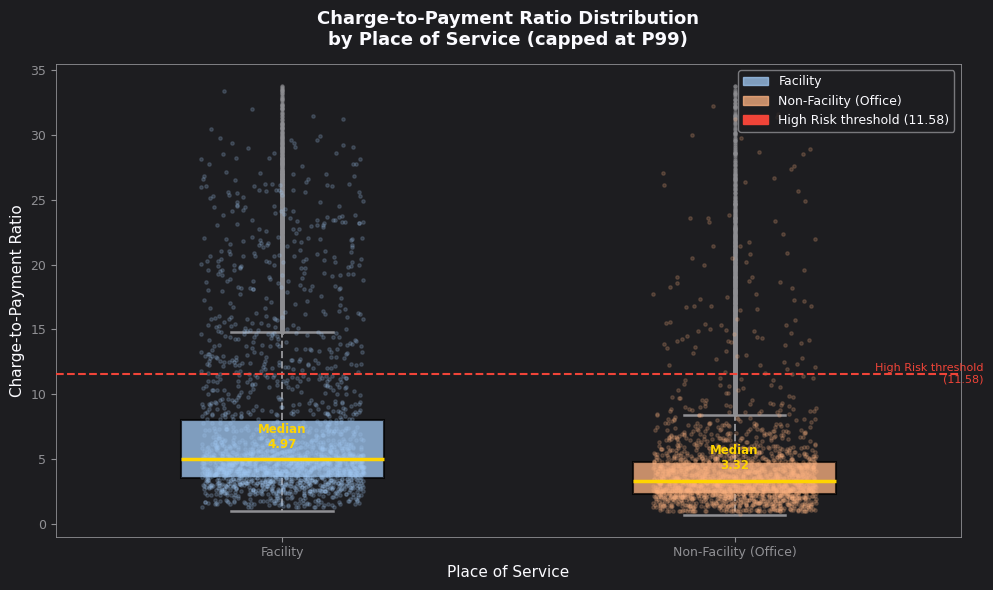

In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Zerve palette ──────────────────────────────────────────────
BG     = "#1D1D20"
TXT    = "#fbfbff"
TXT2   = "#909094"
BLUE   = "#A1C9F4"
ORANGE = "#FFB482"
RED    = "#f04438"
GOLD   = "#ffd400"
GREEN  = "#8DE5A1"

# ── Cap outliers at 99th pct for readability ──────────────────
cap = fraud_df["charge_payment_ratio"].quantile(0.99)
plot_df = fraud_df[fraud_df["charge_payment_ratio"] <= cap].copy()

# ── Standardize place_of_service labels ───────────────────────
pos_map = {"F": "Facility", "O": "Non-Facility (Office)"}
plot_df["pos_label"] = plot_df["place_of_service"].map(pos_map).fillna(plot_df["place_of_service"])

groups   = sorted(plot_df["pos_label"].unique())
n_groups = len(groups)
colors   = [BLUE, ORANGE, GREEN, "#D0BBFF"][:n_groups]

# ── Stats summary ─────────────────────────────────────────────
print("Charge-Payment Ratio by Place of Service (capped at P99 = {:.2f}):".format(cap))
summary = (
    plot_df.groupby("pos_label")["charge_payment_ratio"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(2)
)
print(summary.to_string())

# ── Build figure ──────────────────────────────────────────────
fig_boxplot_pos, ax = plt.subplots(figsize=(10, 6))
fig_boxplot_pos.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Box plot data
data_per_group = [plot_df[plot_df["pos_label"] == g]["charge_payment_ratio"].values for g in groups]

bp = ax.boxplot(
    data_per_group,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops=dict(color=GOLD, linewidth=2.5),
    whiskerprops=dict(color=TXT2, linewidth=1.4, linestyle="--"),
    capprops=dict(color=TXT2, linewidth=1.8),
    flierprops=dict(marker="o", color=TXT2, alpha=0.3, markersize=3,
                    markerfacecolor=TXT2, markeredgewidth=0),
    boxprops=dict(linewidth=1.5),
)

# Color each box
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

# Overlay jittered strip
for i, (g, col) in enumerate(zip(groups, colors), start=1):
    vals = plot_df[plot_df["pos_label"] == g]["charge_payment_ratio"].values
    jitter = np.random.default_rng(42).uniform(-0.18, 0.18, size=min(len(vals), 2000))
    sample = vals[:2000]
    ax.scatter(
        np.full(len(sample), i) + jitter,
        sample,
        alpha=0.18,
        s=6,
        color=col,
        zorder=2,
    )

# Threshold line (3× median)
median_ratio = fraud_df["charge_payment_ratio"].median()
threshold    = median_ratio * 3
ax.axhline(threshold, color=RED, linewidth=1.5, linestyle="--", zorder=3)
ax.text(
    n_groups + 0.55, threshold,
    f"High Risk threshold\n({threshold:.2f})",
    color=RED, fontsize=8, va="center", ha="right"
)

# Annotate median per group
for i, (g, col) in enumerate(zip(groups, colors), start=1):
    med = plot_df[plot_df["pos_label"] == g]["charge_payment_ratio"].median()
    ax.text(
        i, med + (cap * 0.02),
        f"Median\n{med:.2f}",
        ha="center", va="bottom",
        color=GOLD, fontsize=8.5, fontweight="bold"
    )

# Axes styling
ax.set_xticks(range(1, n_groups + 1))
ax.set_xticklabels(groups, color=TXT, fontsize=11)
ax.set_ylabel("Charge-to-Payment Ratio", color=TXT, fontsize=11)
ax.set_xlabel("Place of Service", color=TXT, fontsize=11)
ax.set_title(
    "Charge-to-Payment Ratio Distribution\nby Place of Service (capped at P99)",
    color=TXT, fontsize=13, fontweight="bold", pad=14
)

ax.tick_params(colors=TXT2, labelsize=9)
ax.yaxis.label.set_color(TXT)
ax.xaxis.label.set_color(TXT)

for spine in ax.spines.values():
    spine.set_edgecolor(TXT2)
    spine.set_linewidth(0.6)
ax.set_facecolor(BG)

# Legend
legend_patches = [mpatches.Patch(color=c, alpha=0.75, label=g) for c, g in zip(colors, groups)]
legend_patches.append(mpatches.Patch(color=RED, label=f"High Risk threshold ({threshold:.2f})"))
ax.legend(
    handles=legend_patches,
    loc="upper right",
    facecolor=BG,
    edgecolor=TXT2,
    labelcolor=TXT,
    fontsize=9,
)

plt.tight_layout()
plt.show()


# Fraud Vizualization - Top 15 Providers by Services per Beneficiary 

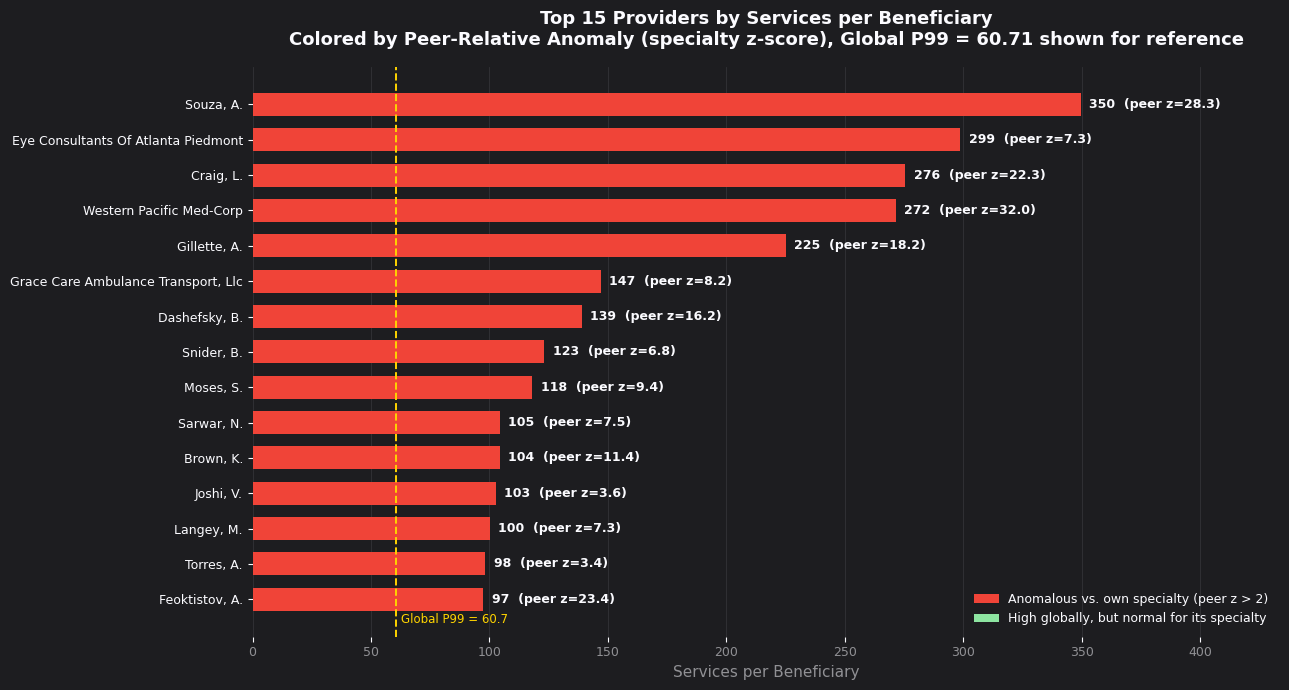

Services per Beneficiary — 99th Percentile Threshold (global) : 60.71
High Utilization providers flagged (global)                   : 1,000

All 15 rows above clear the GLOBAL threshold by construction (that's why they're
in a top-15-by-SPB list) -- the peer z-score column below is what actually
distinguishes genuinely anomalous providers from naturally high-volume specialties:

Top 15 Providers by Services per Beneficiary:
                              label                              provider_type    spb  spb_zscore_peer
                          Souza, A.                         Nurse Practitioner 349.80            28.33
Eye Consultants Of Atlanta Piedmont                 Ambulatory Surgical Center 298.82             7.32
                          Craig, L.                         Nurse Practitioner 275.54            22.28
           Western Pacific Med-Corp                   Opioid Treatment Program 271.50            31.97
                       Gillette, A.                      

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

BG        = "#1D1D20"
TXT       = "#fbfbff"
TXT2      = "#909094"
RED       = "#f04438"
SAFE      = "#8DE5A1"
THRESHOLD = spb_threshold   # 99th percentile from fraud detection block

# aggregate by provider — sum services & beneficiaries then recompute SPB
_prov_agg = (
    fraud_df
    .groupby(["npi", "provider_last_org_name", "provider_first_name", "provider_type"], as_index=False)
    .agg(total_services=("total_services", "sum"),
         total_beneficiaries=("total_beneficiaries", "sum"))
)
_prov_agg["spb"] = _prov_agg["total_services"] / _prov_agg["total_beneficiaries"]

# ── Peer-relative context ────────────────────────────────────────────────────
# A raw "top 15 by SPB" list is, by construction, always going to clear the
# global P99 threshold -- every bar in this chart would be red under that
# rule, making the above/below-threshold coloring meaningless. What actually
# varies is whether a provider is unusual FOR THEIR OWN SPECIALTY: an Opioid
# Treatment Program or Ambulance Service naturally sees the same small panel
# of patients very frequently (daily dosing, repeat transports) as part of
# normal business, while the same raw SPB for an individual Nurse
# Practitioner or Rheumatologist is far more anomalous. We compute each
# provider's SPB as a z-score relative to their own provider_type peers
# (falling back to the global mean/std for specialties with <30 providers)
# and use THAT to color the bars instead.
_MIN_PEER_N = 30
_grp        = _prov_agg.groupby("provider_type")["spb"]
_peer_mean  = _grp.transform("mean")
_peer_std   = _grp.transform("std")
_peer_n     = _grp.transform("count")
_global_mean = _prov_agg["spb"].mean()
_global_std  = _prov_agg["spb"].std()
_mean = np.where(_peer_n >= _MIN_PEER_N, _peer_mean, _global_mean)
_std  = np.where((_peer_n >= _MIN_PEER_N) & (_peer_std > 0), _peer_std, _global_std)
_prov_agg["spb_zscore_peer"] = (_prov_agg["spb"] - _mean) / _std

# build clean label
_prov_agg["label"] = _prov_agg.apply(
    lambda r: r["provider_last_org_name"] if r["provider_first_name"] in ("Unknown", "", "N/A")
    else f"{r['provider_last_org_name']}, {r['provider_first_name'][0]}.",
    axis=1
)

top15_spb = _prov_agg.nlargest(15, "spb").reset_index(drop=True)

# ── Chart ──────────────────────────────────────────────────────────────────────
fig_spb, ax = plt.subplots(figsize=(13, 7))
fig_spb.patch.set_facecolor(BG)
ax.set_facecolor(BG)

_labels    = top15_spb["label"].tolist()
_spb_vals  = top15_spb["spb"].tolist()
_peer_z    = top15_spb["spb_zscore_peer"].tolist()
# Color by peer-relative anomaly (z > 2), not the global P99 threshold --
# every one of these rows already clears the global threshold, so that
# coloring never varies. Peer z-score DOES vary: naturally high-volume
# specialties (e.g. Opioid Treatment Program, Ambulance Service) can have a
# low peer z-score despite a huge raw SPB, while a Nurse Practitioner with
# the same raw SPB can be extremely anomalous relative to peers.
_bar_colors = [RED if z > 2 else SAFE for z in _peer_z]

_bars = ax.barh(_labels[::-1], _spb_vals[::-1], color=_bar_colors[::-1],
                edgecolor="none", height=0.65, zorder=3)

# global threshold reference line (kept for context, but no longer drives color)
ax.axvline(x=THRESHOLD, color="#ffd400", linewidth=1.4, linestyle="--", zorder=4)

# value labels: raw SPB + peer z-score, so it's clear WHY a bar is colored the way it is
for _bar, _val, _z in zip(_bars, _spb_vals[::-1], _peer_z[::-1]):
    ax.text(_bar.get_width() + max(_spb_vals) * 0.01,
            _bar.get_y() + _bar.get_height() / 2,
            f"{_val:,.0f}  (peer z={_z:,.1f})", va="center", ha="left",
            color=TXT, fontsize=9, fontweight="bold")

ax.set_title(
    f"Top 15 Providers by Services per Beneficiary\nColored by Peer-Relative Anomaly (specialty z-score), Global P99 = {THRESHOLD:.2f} shown for reference",
    color=TXT, fontsize=13, fontweight="bold", pad=16
)
ax.set_xlabel("Services per Beneficiary", color=TXT2, fontsize=11)
ax.tick_params(colors=TXT, labelsize=9)
ax.xaxis.set_tick_params(labelcolor=TXT2)
ax.set_xlim(0, max(_spb_vals) * 1.24)
ax.xaxis.grid(True, color="#333337", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for _spine in ax.spines.values():
    _spine.set_visible(False)

# threshold label on the line
ax.text(THRESHOLD + max(_spb_vals) * 0.005, ax.get_ylim()[0] + 0.3,
        f"Global P99 = {THRESHOLD:.1f}", color="#ffd400", fontsize=8.5, va="bottom")

_legend_elements = [
    Patch(facecolor=RED,  label="Anomalous vs. own specialty (peer z > 2)"),
    Patch(facecolor=SAFE, label="High globally, but normal for its specialty"),
]
ax.legend(handles=_legend_elements, frameon=False, labelcolor=TXT, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

print(f"Services per Beneficiary — 99th Percentile Threshold (global) : {THRESHOLD:.2f}")
print(f"High Utilization providers flagged (global)                   : {(fraud_df['services_per_beneficiary'] > THRESHOLD).sum():,}")
print(f"\nAll 15 rows above clear the GLOBAL threshold by construction (that's why they're")
print(f"in a top-15-by-SPB list) -- the peer z-score column below is what actually")
print(f"distinguishes genuinely anomalous providers from naturally high-volume specialties:")
print(f"\nTop 15 Providers by Services per Beneficiary:")
print(top15_spb[["label", "provider_type", "spb", "spb_zscore_peer"]].to_string(index=False))


# Fraud Vizualization - Top 10 states by High Risk count 

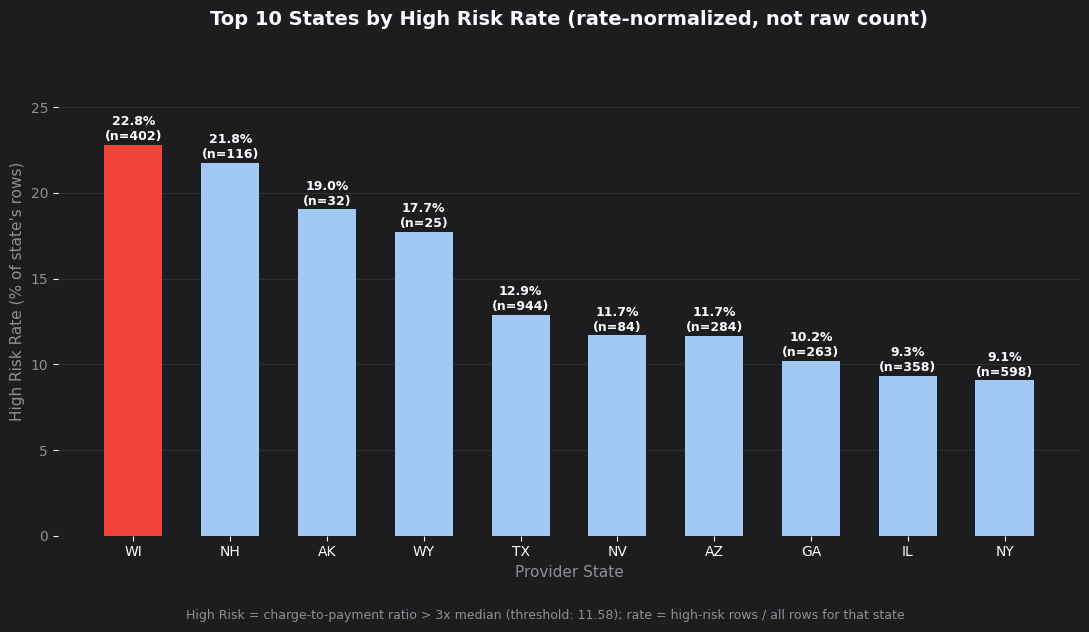

Top 10 States by High Risk Rate:
provider_state  high_risk_count  total_rows  high_risk_rate
            WI              402        1763            0.23
            NH              116         533            0.22
            AK               32         168            0.19
            WY               25         141            0.18
            TX              944        7327            0.13
            NV               84         719            0.12
            AZ              284        2435            0.12
            GA              263        2576            0.10
            IL              358        3840            0.09
            NY              598        6601            0.09


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BG   = "#1D1D20"
TXT  = "#fbfbff"
TXT2 = "#909094"
RED  = "#f04438"
BAR  = "#A1C9F4"

# Top 10 states by high-risk RATE (high-risk count / total provider rows in
# that state), not raw count -- a raw count is confounded by how many
# providers/rows a state has in the first place (e.g. TX and CA simply have
# more claims overall, so they'll show more "high risk" rows even at the same
# underlying rate).
_state_totals = claims_df.groupby("provider_state").size().rename("total_rows")
state_risk = (
    fraud_df[fraud_df["potential_fraud"] == "High Risk"]
    .groupby("provider_state")
    .size()
    .reset_index(name="high_risk_count")
    .merge(_state_totals, on="provider_state")
)
state_risk["high_risk_rate"] = state_risk["high_risk_count"] / state_risk["total_rows"]
state_risk = state_risk.sort_values("high_risk_rate", ascending=False).head(10)

fig_state_risk, ax = plt.subplots(figsize=(11, 6))
fig_state_risk.patch.set_facecolor(BG)
ax.set_facecolor(BG)

states = state_risk["provider_state"].tolist()
rates  = (state_risk["high_risk_rate"] * 100).tolist()
colors = [RED if i == 0 else BAR for i in range(len(states))]

bars = ax.bar(states, rates, color=colors, edgecolor="none", zorder=3, width=0.6)

for bar, val, cnt in zip(bars, rates, state_risk["high_risk_count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%\n(n={cnt:,})", ha="center", va="bottom", color=TXT, fontsize=9, fontweight="bold")

ax.set_title("Top 10 States by High Risk Rate (rate-normalized, not raw count)", color=TXT, fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Provider State", color=TXT2, fontsize=11)
ax.set_ylabel("High Risk Rate (% of state's rows)", color=TXT2, fontsize=11)
ax.tick_params(colors=TXT, labelsize=10)
ax.yaxis.set_tick_params(labelcolor=TXT2)
ax.set_ylim(0, max(rates) * 1.25)
ax.yaxis.grid(True, color="#333337", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

_note = f"High Risk = charge-to-payment ratio > 3x median (threshold: {fraud_df['charge_payment_ratio'].median()*3:.2f}); rate = high-risk rows / all rows for that state"
fig_state_risk.text(0.5, -0.04, _note, ha="center", color=TXT2, fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 States by High Risk Rate:")
print(state_risk[["provider_state", "high_risk_count", "total_rows", "high_risk_rate"]].to_string(index=False))


# Data Quality Investigation - SPB Outliers & Non-State Codes


In [31]:
import pandas as pd
import numpy as np

# ── Investigate extreme services-per-beneficiary values ────────────────────
_extreme_spb = fraud_df[fraud_df["services_per_beneficiary"] > 500][
    ["npi", "provider_last_org_name", "provider_type", "provider_state",
     "hcpcs_code", "total_services", "total_beneficiaries",
     "services_per_beneficiary"]
].sort_values("services_per_beneficiary", ascending=False)

print("=" * 70)
print("ROWS WITH SERVICES-PER-BENEFICIARY > 500")
print("=" * 70)
print(f"Row count: {len(_extreme_spb):,}")
if len(_extreme_spb):
    print(f"\nProvider types involved:\n{_extreme_spb['provider_type'].value_counts().to_string()}")
    print(f"\nTop 10 most extreme rows:")
    print(_extreme_spb.head(10).to_string(index=False))
    print(
        "\nInterpretation: these are single HCPCS-code line items (not full-provider "
        "totals), so a small total_beneficiaries denominator on one procedure code can "
        "produce a very large SPB even for a legitimate high-frequency service (e.g. "
        "daily dialysis or opioid-treatment dosing). This is a genuine feature of "
        "line-item-level billing data, not an obvious data-entry error -- but it means "
        "provider-level SPB aggregates (see 'Top 15 Providers by Services per "
        "Beneficiary' below) that sum services/beneficiaries across many HCPCS rows "
        "before dividing can still be distorted if a provider's rows don't all share "
        "the same beneficiary population. We keep these rows (no justification to "
        "treat them as errors) but surface them explicitly here rather than silently "
        "accepting the provider-level SPB ranking at face value."
    )

# ── Investigate the "AE" (Armed Forces Europe) state code ───────────────────
_ae_rows = claims_df[claims_df["provider_state"] == "AE"]
print("\n" + "=" * 70)
print("'AE' (ARMED FORCES EUROPE) STATE CODE CHECK")
print("=" * 70)
print(f"Row count       : {len(_ae_rows):,}")
print(f"Unique providers: {_ae_rows['npi'].nunique():,}")
if len(_ae_rows):
    print(f"Mean avg_submitted_charge for AE rows: ${_ae_rows['avg_submitted_charge'].mean():,.2f}")
print(
    "\nInterpretation: 'AE' is a military postal code, not a US state. With only a "
    "handful of providers, a couple of high-charge claims can dominate a simple mean "
    "and make AE look like a top-charge 'state' by chance. The 'Top 10 States by "
    "Average Submitted Charge' chart excludes non-US-state/territory codes (AA, AE, "
    "AP) and annotates sample size per state so small-n entries can't masquerade as "
    "genuine geographic hotspots."
)


ROWS WITH SERVICES-PER-BENEFICIARY > 500
Row count: 204

Provider types involved:
provider_type
Hematology-Oncology                     63
Rheumatology                            30
Medical Oncology                        25
Nurse Practitioner                      23
Neurology                               20
Internal Medicine                        8
Physical Medicine and Rehabilitation     8
Allergy/ Immunology                      5
Orthopedic Surgery                       3
Infectious Disease                       3
Urology                                  3
Gastroenterology                         3
Pulmonary Disease                        2
Endocrinology                            2
Physician Assistant                      2
Pediatric Medicine                       1
Ambulatory Surgical Center               1
Ophthalmology                            1
General Practice                         1

Top 10 most extreme rows:
       npi provider_last_org_name       provider_type provid

# Distribution - Services per beneficiary

  SERVICES PER BENEFICIARY — DISTRIBUTION STATS
  Mean              : 5.56
  Median (P50)      : 1.07
  P75               : 1.47
  P90               : 3.11
  P95               : 6.68
  P99 (threshold)   : 60.71
  Max               : 7934.34
  Rows > P99        : 1,000  (1.0%)


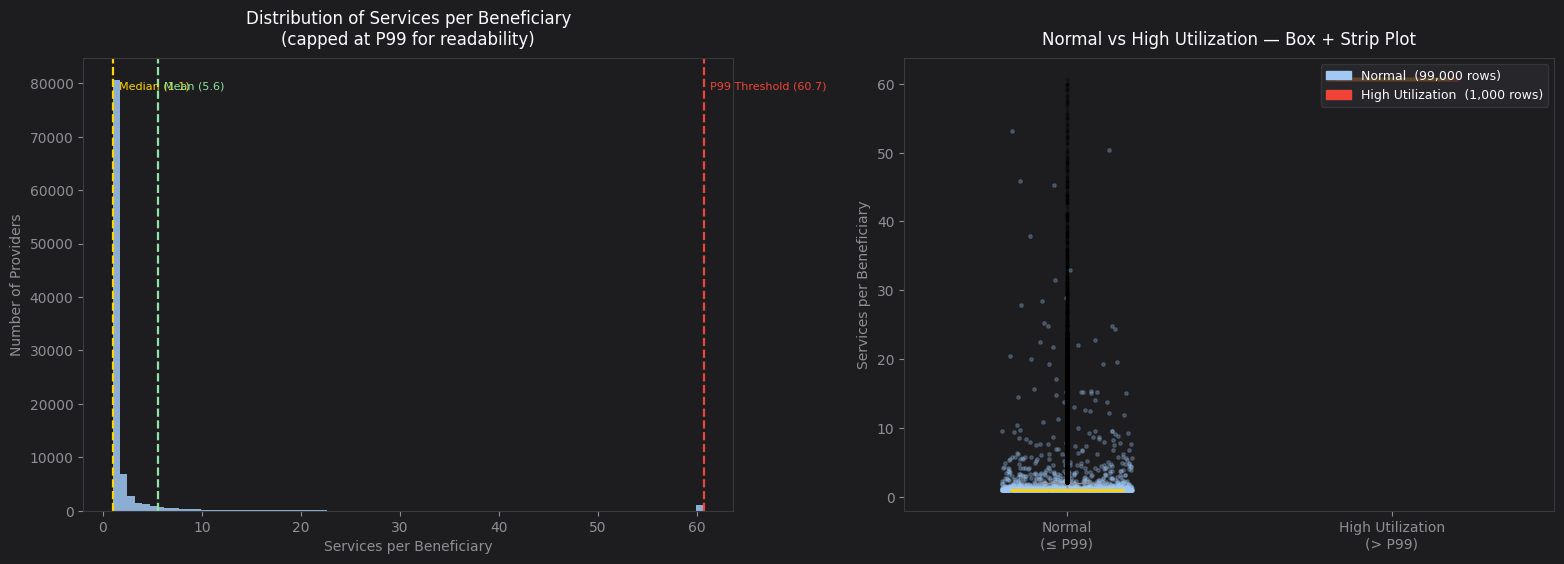

In [32]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG   = "#1D1D20"
TXT  = "#fbfbff"
TXT2 = "#909094"
BLUE = "#A1C9F4"
RED  = "#f04438"
GOLD = "#ffd400"

spb = fraud_df["services_per_beneficiary"]

# Key stats
p50  = spb.median()
p75  = spb.quantile(0.75)
p90  = spb.quantile(0.90)
p95  = spb.quantile(0.95)
p99  = spb.quantile(0.99)
mean = spb.mean()
cap  = p99   # cap for readable histogram x-axis

print("=" * 55)
print("  SERVICES PER BENEFICIARY — DISTRIBUTION STATS")
print("=" * 55)
print(f"  Mean              : {mean:.2f}")
print(f"  Median (P50)      : {p50:.2f}")
print(f"  P75               : {p75:.2f}")
print(f"  P90               : {p90:.2f}")
print(f"  P95               : {p95:.2f}")
print(f"  P99 (threshold)   : {p99:.2f}")
print(f"  Max               : {spb.max():.2f}")
print(f"  Rows > P99        : {(spb > p99).sum():,}  ({(spb > p99).mean()*100:.1f}%)")
print("=" * 55)

# ── Figure: 2 panels side by side ──────────────────────────
fig_spb_dist, axes = plt.subplots(1, 2, figsize=(16, 6))
fig_spb_dist.patch.set_facecolor(BG)

# ── Panel 1: Full distribution histogram (capped at P99) ───
ax1 = axes[0]
ax1.set_facecolor(BG)

_spb_capped = spb.clip(upper=cap)
_n, _bins, _patches = ax1.hist(_spb_capped, bins=80, color=BLUE, alpha=0.85, edgecolor="none")

# Colour bars above P99 threshold in red
for _patch, _left in zip(_patches, _bins[:-1]):
    if _left >= p99:
        _patch.set_facecolor(RED)
        _patch.set_alpha(0.9)

# Reference lines
for _val, _color, _lbl in [
    (p50, GOLD,       f"Median ({p50:.1f})"),
    (p99, RED,        f"P99 Threshold ({p99:.1f})"),
    (mean, "#8DE5A1", f"Mean ({mean:.1f})"),
]:
    ax1.axvline(_val, color=_color, linewidth=1.6, linestyle="--")
    ax1.text(_val + cap * 0.01, ax1.get_ylim()[1] * 0.95,
             _lbl, color=_color, fontsize=8, va="top")

ax1.set_title("Distribution of Services per Beneficiary\n(capped at P99 for readability)",
              color=TXT, fontsize=12, pad=10)
ax1.set_xlabel("Services per Beneficiary", color=TXT2, fontsize=10)
ax1.set_ylabel("Number of Providers", color=TXT2, fontsize=10)
ax1.tick_params(colors=TXT2)
for sp in ax1.spines.values():
    sp.set_edgecolor("#3a3a3e")
ax1.xaxis.label.set_color(TXT2)
ax1.yaxis.label.set_color(TXT2)

# ── Panel 2: Box plot + strip showing risk tiers ────────────
ax2 = axes[1]
ax2.set_facecolor(BG)

_normal   = spb[spb <= p99].clip(upper=cap)
_highrisk = spb[spb > p99].clip(upper=cap)

# Jitter strip for both tiers
_rng = np.random.default_rng(42)
for _tier_data, _color, _x in [
    (_normal,   BLUE, 0),
    (_highrisk, RED,  1),
]:
    _jitter = _rng.uniform(-0.2, 0.2, size=min(len(_tier_data), 2000))
    _sample = _tier_data.sample(min(len(_tier_data), 2000), random_state=42)
    ax2.scatter(_jitter + _x, _sample.values,
                color=_color, alpha=0.25, s=6, zorder=2)

# Box plots
_bp = ax2.boxplot(
    [_normal.values, _highrisk.values],
    positions=[0, 1],
    widths=0.35,
    patch_artist=True,
    medianprops=dict(color=GOLD, linewidth=2),
    whiskerprops=dict(color=TXT2),
    capprops=dict(color=TXT2),
    flierprops=dict(marker=".", color=TXT2, alpha=0.2, markersize=3),
)
_bp["boxes"][0].set_facecolor("#A1C9F430")
_bp["boxes"][0].set_edgecolor(BLUE)
_bp["boxes"][1].set_facecolor("#f0443830")
_bp["boxes"][1].set_edgecolor(RED)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Normal\n(≤ P99)", "High Utilization\n(> P99)"], color=TXT2, fontsize=10)
ax2.set_title("Normal vs High Utilization — Box + Strip Plot",
              color=TXT, fontsize=12, pad=10)
ax2.set_ylabel("Services per Beneficiary", color=TXT2, fontsize=10)
ax2.tick_params(colors=TXT2)
for sp in ax2.spines.values():
    sp.set_edgecolor("#3a3a3e")

_legend = [
    mpatches.Patch(color=BLUE, label=f"Normal  ({len(_normal):,} rows)"),
    mpatches.Patch(color=RED,  label=f"High Utilization  ({len(_highrisk):,} rows)"),
]
ax2.legend(handles=_legend, facecolor="#2a2a2e", edgecolor="#3a3a3e",
           labelcolor=TXT, fontsize=9, loc="upper right")

plt.tight_layout(pad=2.0)
plt.show()

# Random Forest Fraud Classifier

Dataset shape : 100,000 rows x 4 features
Fraud rate    : 8.1%  (8,084 High Risk / 91,916 Normal)

Features used : ['total_services', 'total_beneficiaries', 'avg_medicare_allowed_amt', 'avg_medicare_standardized_amt']

(avg_submitted_charge and avg_medicare_payment_amt were dropped from the feature set -- they are the exact inputs used to construct the label's charge_payment_ratio, so including them made the earlier model's near-perfect ROC-AUC circular rather than a genuine test of predictive power.)

Training set  : 80,000 rows  (8.1% fraud)
Test set      : 20,000 rows  (8.1% fraud)

  RANDOM FOREST -- MODEL PERFORMANCE (non-circular feature set)
  Accuracy   : 0.7478  (74.78%)
  Precision  : 0.1747  (17.47%)
  Recall     : 0.5690  (56.90%)
  F1 Score   : 0.2673  (26.73%)
  ROC-AUC    : 0.7492

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.76      0.85     18383
   High Risk       0.17      0.57      0.27      1617

    a

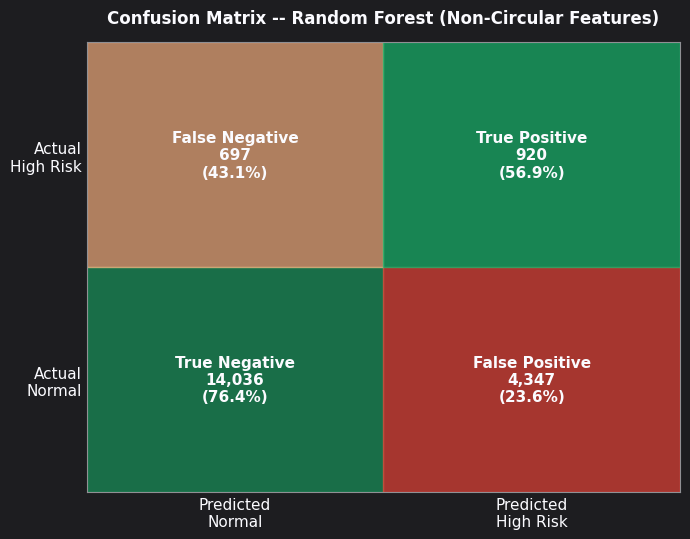

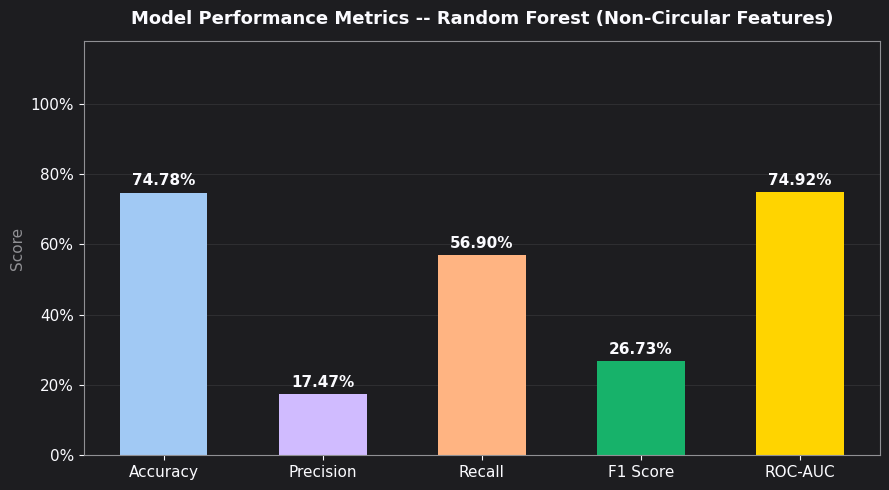

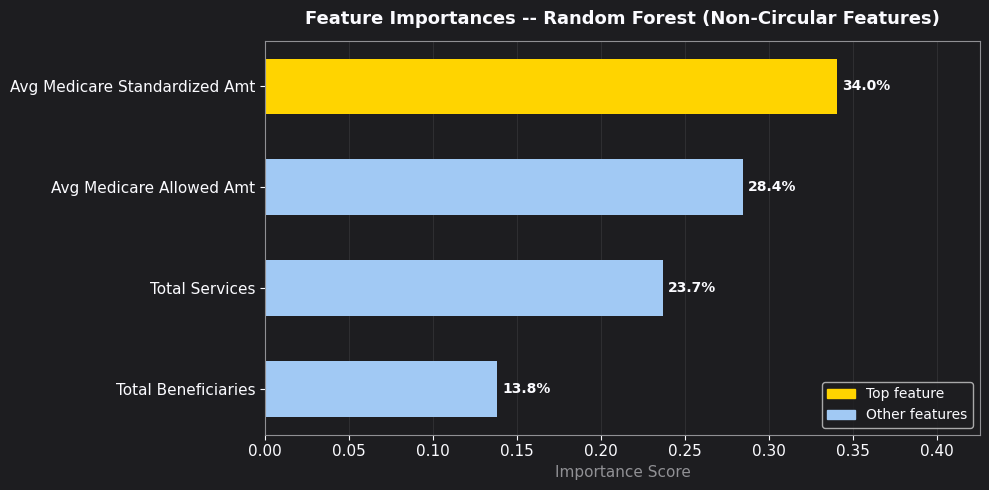

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# ── Prepare Features & Target ──────────────────────────────────────────────────

# NOTE: avg_submitted_charge and avg_medicare_payment_amt are EXCLUDED here.
# potential_fraud was derived deterministically from
# charge_payment_ratio = avg_submitted_charge / avg_medicare_payment_amt, so
# feeding those same two raw columns back in as features lets a tree ensemble
# reconstruct the ratio (or something highly correlated with it) via splits --
# that circularity is what produced the earlier ROC-AUC of 0.9998. Excluding
# both label-defining inputs is required for the model to be evaluated on
# genuinely independent signal.
FEATURES = [
    'total_services',
    'total_beneficiaries',
    'avg_medicare_allowed_amt',
    'avg_medicare_standardized_amt'
]

# Target: 1 = High Risk, 0 = Normal  (based on potential_fraud column)
_model_df = fraud_df[FEATURES + ['potential_fraud']].dropna().copy()
_model_df['fraud_flag'] = (_model_df['potential_fraud'] == 'High Risk').astype(int)

X = _model_df[FEATURES]
y = _model_df['fraud_flag']

print(f"Dataset shape : {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Fraud rate    : {y.mean()*100:.1f}%  ({y.sum():,} High Risk / {(y==0).sum():,} Normal)")
print(f"\nFeatures used : {FEATURES}")
print(
    "\n(avg_submitted_charge and avg_medicare_payment_amt were dropped from the "
    "feature set -- they are the exact inputs used to construct the label's "
    "charge_payment_ratio, so including them made the earlier model's near-perfect "
    "ROC-AUC circular rather than a genuine test of predictive power.)"
)

# ── Train / Test Split (80/20 stratified) ─────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set  : {X_train.shape[0]:,} rows  ({y_train.mean()*100:.1f}% fraud)")
print(f"Test set      : {X_test.shape[0]:,} rows  ({y_test.mean()*100:.1f}% fraud)")

# ── Train Random Forest ────────────────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# ── Predictions ────────────────────────────────────────────────────────────────

y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# ── Metrics ────────────────────────────────────────────────────────────────────

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)
cm        = confusion_matrix(y_test, y_pred)

print("\n" + "="*60)
print("  RANDOM FOREST -- MODEL PERFORMANCE (non-circular feature set)")
print("="*60)
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision  : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall     : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score   : {f1:.4f}  ({f1*100:.2f}%)")
print(f"  ROC-AUC    : {roc_auc:.4f}")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'High Risk'], zero_division=0))

# ── Feature Importances ────────────────────────────────────────────────────────

feat_importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nFeature Importances:")
print(feat_importance_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

BG       = '#1D1D20'
TXT      = '#fbfbff'
TXT2     = '#909094'
RED      = '#f04438'
GREEN    = '#17b26a'
BLUE     = '#A1C9F4'
ORANGE   = '#FFB482'
GOLD     = '#ffd400'
LAVENDER = '#D0BBFF'
CORAL    = '#FF9F9B'

# ── Chart 1 — Confusion Matrix ─────────────────────────────────────────────────

fig_cm, ax_cm = plt.subplots(figsize=(7, 5.5))
fig_cm.patch.set_facecolor(BG)
ax_cm.set_facecolor(BG)

tn, fp, fn, tp = cm.ravel()
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

_cell_colors = [
    [GREEN,  RED   ],
    [ORANGE, GREEN ],
]
_cell_alphas = [
    [0.55, 0.65],
    [0.65, 0.70],
]
_labels = [
    [f"True Negative\n{tn:,}\n({cm_norm[0,0]*100:.1f}%)",
     f"False Positive\n{fp:,}\n({cm_norm[0,1]*100:.1f}%)"],
    [f"False Negative\n{fn:,}\n({cm_norm[1,0]*100:.1f}%)",
     f"True Positive\n{tp:,}\n({cm_norm[1,1]*100:.1f}%)"]
]

for i in range(2):
    for j in range(2):
        ax_cm.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            color=_cell_colors[i][j], alpha=_cell_alphas[i][j], zorder=1
        ))
        ax_cm.text(j, i, _labels[i][j], ha='center', va='center',
                   color=TXT, fontsize=11, fontweight='bold', zorder=2)

ax_cm.set_xlim(-0.5, 1.5)
ax_cm.set_ylim(-0.5, 1.5)
ax_cm.set_xticks([0, 1])
ax_cm.set_xticklabels(['Predicted\nNormal', 'Predicted\nHigh Risk'], color=TXT, fontsize=11)
ax_cm.set_yticks([0, 1])
ax_cm.set_yticklabels(['Actual\nNormal', 'Actual\nHigh Risk'], color=TXT, fontsize=11)
ax_cm.tick_params(colors=TXT, length=0)
ax_cm.set_title('Confusion Matrix -- Random Forest (Non-Circular Features)',
                color=TXT, fontsize=12, fontweight='bold', pad=14)
for spine in ax_cm.spines.values():
    spine.set_edgecolor(TXT2)

plt.tight_layout()
fig_confusion_matrix = fig_cm
plt.show()

# ── Chart 2 — Metric Bars ──────────────────────────────────────────────────────

_metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
_metric_values = [accuracy, precision, recall, f1, roc_auc]
_bar_colors    = [BLUE, LAVENDER, ORANGE, GREEN, GOLD]

fig_metrics, ax_met = plt.subplots(figsize=(9, 5))
fig_metrics.patch.set_facecolor(BG)
ax_met.set_facecolor(BG)

_bars = ax_met.bar(_metric_names, _metric_values,
                    color=_bar_colors, width=0.55, zorder=2)

for _bar, _val in zip(_bars, _metric_values):
    ax_met.text(_bar.get_x() + _bar.get_width() / 2,
                _bar.get_height() + 0.012,
                f'{_val*100:.2f}%',
                ha='center', va='bottom', color=TXT, fontsize=11, fontweight='bold')

ax_met.set_ylim(0, 1.18)
ax_met.set_ylabel('Score', color=TXT2, fontsize=11)
ax_met.set_title('Model Performance Metrics -- Random Forest (Non-Circular Features)',
                  color=TXT, fontsize=13, fontweight='bold', pad=12)
ax_met.tick_params(colors=TXT, labelsize=11)
_yticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax_met.set_yticks(_yticks)
ax_met.set_yticklabels([f'{int(v*100)}%' for v in _yticks], color=TXT)
ax_met.grid(axis='y', color=TXT2, alpha=0.15, zorder=1)
for spine in ax_met.spines.values():
    spine.set_edgecolor(TXT2)

plt.tight_layout()
plt.show()

# ── Chart 3 — Feature Importances ─────────────────────────────────────────────

_feat_sorted  = feat_importance_df.sort_values('importance')
_feat_labels  = [f.replace('_', ' ').title() for f in _feat_sorted['feature']]
_max_imp      = _feat_sorted['importance'].max()
_feat_colors  = [GOLD if v == _max_imp else BLUE for v in _feat_sorted['importance']]

fig_feature_importance, ax_fi = plt.subplots(figsize=(10, 5))
fig_feature_importance.patch.set_facecolor(BG)
ax_fi.set_facecolor(BG)

_hbars = ax_fi.barh(_feat_labels, _feat_sorted['importance'],
                     color=_feat_colors, height=0.55, zorder=2)

for _hbar, _val in zip(_hbars, _feat_sorted['importance']):
    ax_fi.text(_val + 0.003, _hbar.get_y() + _hbar.get_height() / 2,
               f'{_val*100:.1f}%', va='center', color=TXT, fontsize=10, fontweight='bold')

ax_fi.set_xlabel('Importance Score', color=TXT2, fontsize=11)
ax_fi.set_title('Feature Importances -- Random Forest (Non-Circular Features)',
                 color=TXT, fontsize=13, fontweight='bold', pad=12)
ax_fi.tick_params(colors=TXT, labelsize=11)
ax_fi.set_xlim(0, _max_imp * 1.25)
ax_fi.grid(axis='x', color=TXT2, alpha=0.15, zorder=1)
for spine in ax_fi.spines.values():
    spine.set_edgecolor(TXT2)

_gold_patch = mpatches.Patch(color=GOLD, label='Top feature')
_blue_patch = mpatches.Patch(color=BLUE, label='Other features')
ax_fi.legend(handles=[_gold_patch, _blue_patch], facecolor=BG,
             labelcolor=TXT, fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()


# Fraud Vizualization - Average submitted Charge vs Medicare Payment (Fraud Risk)

/var/folders/1w/gdlbhzx57wn489ztk0lds0l40000gn/T/ipykernel_95507/625970612.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"${int(v):,}" for v in _xticks if v >= 0])
/var/folders/1w/gdlbhzx57wn489ztk0lds0l40000gn/T/ipykernel_95507/625970612.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"${int(v):,}" for v in _yticks if v >= 0])


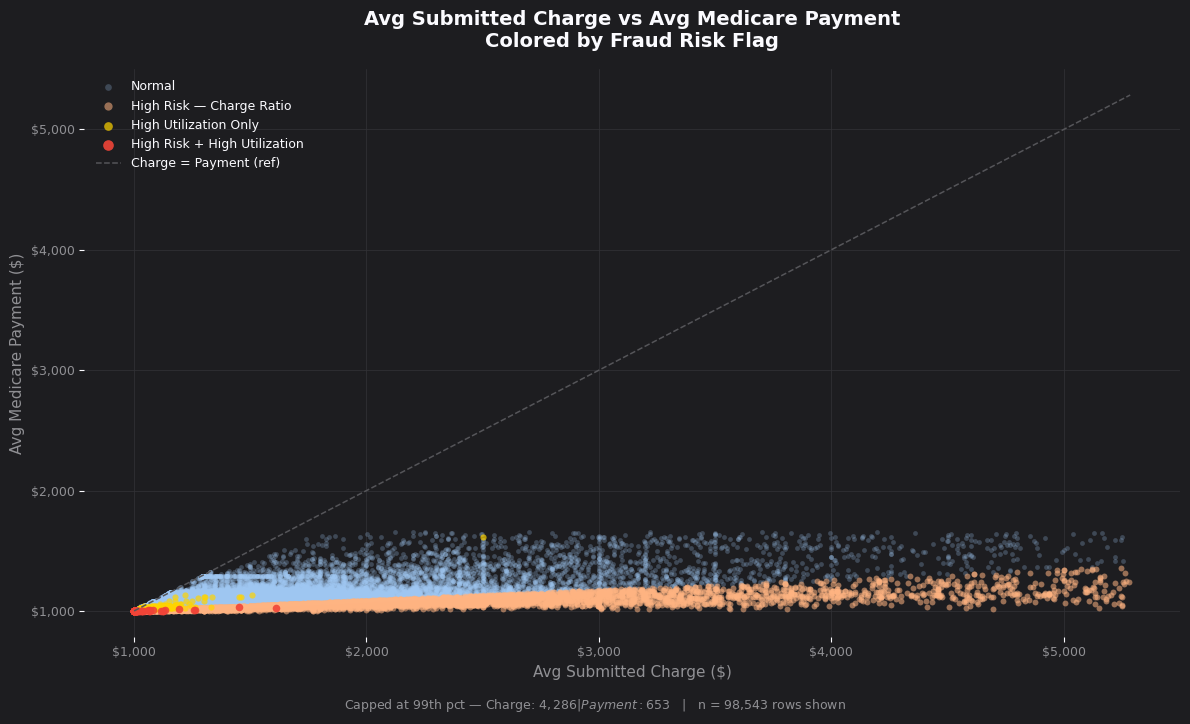

Scatter breakdown:
  Normal (blue)                   : 90,054
  High Risk ratio only (orange)   : 7,499
  High Utilization only (gold)    : 831
  Both flags — top risk (red)     : 159
  Total plotted (99th pct cap)    : 98,543


In [34]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG     = "#1D1D20"
TXT    = "#fbfbff"
TXT2   = "#909094"
RED    = "#f04438"
BLUE   = "#A1C9F4"
ORANGE = "#FFB482"
GOLD   = "#ffd400"

# cap at 99th percentile for readability
_cap_x = fraud_df["avg_submitted_charge"].quantile(0.99)
_cap_y = fraud_df["avg_medicare_payment_amt"].quantile(0.99)
_plot  = fraud_df[
    (fraud_df["avg_submitted_charge"] <= _cap_x) &
    (fraud_df["avg_medicare_payment_amt"] <= _cap_y)
].copy()

# colour mapping: both flags > ratio only > utilization only > normal
def _risk_color(row):
    if row["potential_fraud"] == "High Risk" and row["utilization_flag"] == "High Utilization":
        return RED
    elif row["potential_fraud"] == "High Risk":
        return ORANGE
    elif row["utilization_flag"] == "High Utilization":
        return GOLD
    return BLUE

_plot["_color"] = _plot.apply(_risk_color, axis=1)

# shuffle so red points render on top
_order = {RED: 3, ORANGE: 2, GOLD: 2, BLUE: 1}
_plot["_z"] = _plot["_color"].map(_order)
_plot = _plot.sort_values("_z")

fig_fraud_scatter, ax = plt.subplots(figsize=(12, 7))
fig_fraud_scatter.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# plot each risk tier separately for controlled alpha and zorder
for color, label, alpha, size, zorder in [
    (BLUE,   "Normal",                             0.25, 12, 1),
    (ORANGE, "High Risk — Charge Ratio",           0.55, 18, 2),
    (GOLD,   "High Utilization Only",              0.70, 20, 3),
    (RED,    "High Risk + High Utilization",       0.90, 30, 4),
]:
    _sub = _plot[_plot["_color"] == color]
    ax.scatter(_sub["avg_submitted_charge"], _sub["avg_medicare_payment_amt"],
               c=color, alpha=alpha, s=size, linewidths=0, zorder=zorder, label=label)

# reference line: charge = payment (perfect reimbursement)
_lim = max(_cap_x, _cap_y)
ax.plot([0, _lim], [0, _lim], color="#555559", linewidth=1.1, linestyle="--", zorder=5, label="Charge = Payment (ref)")

ax.set_title("Avg Submitted Charge vs Avg Medicare Payment\nColored by Fraud Risk Flag", color=TXT, fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Avg Submitted Charge ($)", color=TXT2, fontsize=11)
ax.set_ylabel("Avg Medicare Payment ($)", color=TXT2, fontsize=11)
ax.tick_params(colors=TXT, labelsize=9)
ax.xaxis.set_tick_params(labelcolor=TXT2)
ax.yaxis.set_tick_params(labelcolor=TXT2)

# format axis labels as plain $ strings without FuncFormatter
_xticks = ax.get_xticks()
ax.set_xticklabels([f"${int(v):,}" for v in _xticks if v >= 0])
_yticks = ax.get_yticks()
ax.set_yticklabels([f"${int(v):,}" for v in _yticks if v >= 0])

ax.grid(True, color="#333337", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

_legend = ax.legend(frameon=False, labelcolor=TXT, fontsize=9,
                    loc="upper left", markerscale=1.4)

_note = f"Capped at 99th pct — Charge: ${_cap_x:,.0f} | Payment: ${_cap_y:,.0f}   |   n = {len(_plot):,} rows shown"
fig_fraud_scatter.text(0.5, -0.02, _note, ha="center", color=TXT2, fontsize=9)

plt.tight_layout()
plt.show()

_counts = _plot["_color"].value_counts()
print("Scatter breakdown:")
print(f"  Normal (blue)                   : {(_plot['_color']==BLUE).sum():,}")
print(f"  High Risk ratio only (orange)   : {(_plot['_color']==ORANGE).sum():,}")
print(f"  High Utilization only (gold)    : {(_plot['_color']==GOLD).sum():,}")
print(f"  Both flags — top risk (red)     : {(_plot['_color']==RED).sum():,}")
print(f"  Total plotted (99th pct cap)    : {len(_plot):,}")
